In [178]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from graphviz import Digraph
from IPython.display import SVG, display
import networkx as nx
from IPython.display import Image


In [3]:
metadata = pd.read_csv("../data/SPARK.iWES_v3.2024_08.sample_metadata.tsv", sep = "\t")
metadata

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight
0,SP0000003,SF0000003,0,SP0000002,Male,True,123.0,WES1,2018-07-27,0.111,2.070000,90.0000,GSA-v1,3.0,NaN,False,False
1,SP0000002,SF0000003,0,0,Female,False,369.0,WES1,2018-08-29,0.055,2.410000,97.0000,GSA-v1,3.0,NaN,False,False
2,SP0000017,SF0000017,0,0,Male,True,611.0,WES2,2019-11-26,0.179,1.650000,95.0000,GSA-v2,17.0,NaN,False,False
3,SP0000026,SF0000026,SP0255776,SP0000046,Female,True,65.0,WES6,2022-09-12,0.040,1.721284,95.6968,TwistGxS,8.0,NaN,False,False
4,SP0000046,SF0000026,0,0,Female,False,522.0,WES6,2022-09-12,0.132,1.815472,95.3584,TwistGxS,8.0,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142352,SP0318144,SF0583492,0,0,Male,True,192.0,WES3,2020-08-24,0.069,1.730000,98.0000,GSA-v2,12.0,NaN,False,False
142353,SP0318143,SF0583492,SP0325663,SP0318140,Male,True,223.0,WES3,2020-08-24,0.055,1.700000,98.0000,GSA-v2,12.0,NaN,False,False
142354,SP0329625,SF0583492,SP0325663,SP0318140,Male,True,247.0,WES3,2020-08-25,0.041,1.700000,88.0000,GSA-v2,12.0,NaN,False,False
142355,SP0318140,SF0583492,0,0,Female,False,535.0,WES5,2022-03-23,0.069,1.753526,96.7253,TwistGxS,12.0,NaN,False,False


In [4]:
# In order to compare proband and sibling, family size must be at least two
metadata["family size"] = metadata.groupby("sfid")["sfid"].transform("size")
metadata

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
0,SP0000003,SF0000003,0,SP0000002,Male,True,123.0,WES1,2018-07-27,0.111,2.070000,90.0000,GSA-v1,3.0,NaN,False,False,2
1,SP0000002,SF0000003,0,0,Female,False,369.0,WES1,2018-08-29,0.055,2.410000,97.0000,GSA-v1,3.0,NaN,False,False,2
2,SP0000017,SF0000017,0,0,Male,True,611.0,WES2,2019-11-26,0.179,1.650000,95.0000,GSA-v2,17.0,NaN,False,False,1
3,SP0000026,SF0000026,SP0255776,SP0000046,Female,True,65.0,WES6,2022-09-12,0.040,1.721284,95.6968,TwistGxS,8.0,NaN,False,False,3
4,SP0000046,SF0000026,0,0,Female,False,522.0,WES6,2022-09-12,0.132,1.815472,95.3584,TwistGxS,8.0,NaN,False,False,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142352,SP0318144,SF0583492,0,0,Male,True,192.0,WES3,2020-08-24,0.069,1.730000,98.0000,GSA-v2,12.0,NaN,False,False,5
142353,SP0318143,SF0583492,SP0325663,SP0318140,Male,True,223.0,WES3,2020-08-24,0.055,1.700000,98.0000,GSA-v2,12.0,NaN,False,False,5
142354,SP0329625,SF0583492,SP0325663,SP0318140,Male,True,247.0,WES3,2020-08-25,0.041,1.700000,88.0000,GSA-v2,12.0,NaN,False,False,5
142355,SP0318140,SF0583492,0,0,Female,False,535.0,WES5,2022-03-23,0.069,1.753526,96.7253,TwistGxS,12.0,NaN,False,False,5


In [5]:
metadata.sort_values(by = 'family size')

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
31039,SP0087802,SF0087803,0,0,Female,False,459.0,WES9,2023-07-31,0.099,1.664617,96.5565,TwistGxS,17.0,NaN,False,False,1
44963,SP0137984,SF0137984,0,SP0137981,Male,True,199.0,WES2,2019-11-25,0.057,1.690000,98.0000,GSA-v2,14.0,NaN,False,False,1
44940,SP0137856,SF0137857,0,0,Female,False,396.0,WES9,2023-08-11,0.096,1.712776,96.4160,TwistGxS,13.0,NaN,False,False,1
95661,SP0374792,SF0374792,0,0,Male,True,482.0,WES4,2021-04-01,0.038,1.760000,98.0000,NotAvailable,14.0,NaN,False,False,1
73442,SP0272125,SF0272126,0,0,Female,False,475.0,WES9,2023-08-11,0.051,2.316922,95.9674,TwistGxS,2.0,NaN,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108791,SP0422508,SF0422501,SP0422593,SP0422500,Male,False,100.0,WES5,2022-03-30,0.049,1.650493,94.7768,TwistGxS,5.0,SP0422505,False,False,11
108790,SP0422593,SF0422501,0,0,Male,False,556.0,WES5,2022-03-31,0.071,1.650368,96.5851,TwistGxS,5.0,NaN,False,False,11
108799,SP0422509,SF0422501,SP0422593,SP0422500,Female,False,64.0,WES5,2022-03-30,0.048,1.664879,90.7123,TwistGxS,5.0,NaN,False,False,11
108796,SP0422503,SF0422501,SP0422593,SP0422500,Male,True,179.0,WES5,2022-03-30,0.094,1.720000,89.2357,TwistGxS,5.0,NaN,False,False,11


In [176]:
# def family_to_graph_with_roles(df, sfid):
#     fam = df[df["sfid"] == sfid].copy()
#     fam = fam.astype(str)

#     G = nx.DiGraph()
#     role_map = {}  # maps node to "M" or "F" for shape

#     for _, row in fam.iterrows():
#         child = row["spid"]
#         asd_val = row["asd"] if isinstance(row["asd"], bool) else row["asd"] == "True"
#         G.add_node(child, asd=asd_val)
#         # Use 'sex' column for child
#         role_map[child] = "M" if row.get("sex") == "Male" else "F"

#         # Father
#         father = row["father"]
#         if father not in ["0", "NA", "nan", "None"]:
#             if father in df["spid"].values:
#                 f_asd = bool(df.loc[df["spid"] == father, "asd"].squeeze())
#             else:
#                 f_asd = None
#             G.add_node(father, asd=f_asd)
#             G.add_edge(father, child)
#             role_map[father] = "M"

#         # Mother
#         mother = row["mother"]
#         if mother not in ["0", "NA", "nan", "None"]:
#             if mother in df["spid"].values:
#                 m_asd = bool(df.loc[df["spid"] == mother, "asd"].squeeze())
#             else:
#                 m_asd = None
#             G.add_node(mother, asd=m_asd)
#             G.add_edge(mother, child)
#             role_map[mother] = "F"

#     return G, role_map


# def plot_family_graphviz(G, role_map=None):
#     dot = Digraph(comment="Pedigree Tree")
#     dot.attr('node', fontname='Helvetica', fontsize='12')
#     dot.attr('edge', fontname='Helvetica', fontsize='12')

#     for node, data in G.nodes(data=True):
#         asd = data.get("asd", None)
#         color = "#FF9999" if asd else "#CCCCCC"  # red = ASD, gray = unaffected
#         shape = "square" if role_map.get(node) == "M" else "circle"
#         dot.node(node, node, color=color, style="filled", shape=shape)

#     for parent, child in G.edges():
#         dot.edge(parent, child)

#     display(SVG(dot.pipe(format="svg")))


def family_to_graph_with_roles(df, sfid):
    fam = df[df["sfid"] == sfid].copy()
    fam = fam.astype(str)
    display(fam)

    G = nx.DiGraph()
    role_map = {}  # maps node to "M" or "F" for shape

    for _, row in fam.iterrows():
        child = row["spid"]
        asd_val = row["asd"] if isinstance(row["asd"], bool) else row["asd"] == "True"
        age_val = None
        try:
            age_val = float(row["age_m"]) / 12 if row["age_m"] not in ["nan", "NA", "None", "0"] else None
        except Exception:
            pass
        G.add_node(child, asd=asd_val, age=age_val)

        # Use 'sex' column for child
        role_map[child] = "M" if row.get("sex") == "Male" else "F"

        # Father
        father = row["father"]
        if father not in ["0", "NA", "nan", "None"]:
            if father in df["spid"].values:
                father_row = df.loc[df["spid"] == father].iloc[0]
                f_asd = bool(father_row["asd"])
                f_age = float(father_row["age_m"]) / 12 if father_row["age_m"] not in ["nan", "NA", "None", "0"] else None
            else:
                f_asd, f_age = None, None
            G.add_node(father, asd=f_asd, age=f_age)
            G.add_edge(father, child)
            role_map[father] = "M"

        # Mother
        mother = row["mother"]
        if mother not in ["0", "NA", "nan", "None"]:
            if mother in df["spid"].values:
                mother_row = df.loc[df["spid"] == mother].iloc[0]
                m_asd = bool(mother_row["asd"])
                m_age = float(mother_row["age_m"]) / 12 if mother_row["age_m"] not in ["nan", "NA", "None", "0"] else None
            else:
                m_asd, m_age = None, None
            G.add_node(mother, asd=m_asd, age=m_age)
            G.add_edge(mother, child)
            role_map[mother] = "F"

    return G, role_map


def plot_family_graphviz(G, role_map=None, title=None):
    dot = Digraph(comment="Pedigree Tree")
    dot.attr('node', fontname='Helvetica', fontsize='12')
    dot.attr('edge', fontname='Helvetica', fontsize='12')

    if title:
        dot.attr(label=title, labelloc="t", fontsize="16", fontname="Helvetica-Bold")

    for node, data in G.nodes(data=True):
        asd = data.get("asd", None)
        age = data.get("age", None)
        label = node
        if age is not None:
            label += f"\n{age:.1f}y"
        else: 
            print(age)

        color = "#FF9999" if asd else "#CCCCCC"  # red = ASD, gray = unaffected
        shape = "square" if role_map.get(node) == "M" else "circle"
        dot.node(node, label, color=color, style="filled", shape=shape)

    for parent, child in G.edges():
        dot.edge(parent, child)

   #display(SVG(dot.pipe(format="svg")))
    img_bytes = dot.pipe(format="png")
    display(Image(img_bytes))



In [182]:
metadata[metadata["family size"] == 4]

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
38,SP0001673,SF0000145,SP0007039,SP0000111,Male,False,183.0,WES1,2018-07-25,0.058,1.710000,96.0000,GSA-v1,1.0,NaN,False,False,4
39,SP0000111,SF0000145,0,0,Female,False,469.0,WES1,2018-07-25,0.087,1.720000,95.0000,GSA-v1,1.0,NaN,False,False,4
40,SP0007039,SF0000145,0,0,Male,False,507.0,WES1,2018-07-25,0.072,1.750000,97.0000,GSA-v1,1.0,NaN,False,False,4
41,SP0000145,SF0000145,SP0007039,SP0000111,Male,True,159.0,WES1,2018-07-25,0.079,1.660000,97.0000,GSA-v1,1.0,NaN,False,False,4
67,SP0000285,SF0000226,SP0000819,SP0001282,Female,False,128.0,WES1,2018-07-17,0.089,1.760000,95.0000,GSA-v1,10.0,NaN,False,False,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142298,SP0558743,SF0558743,SP0558753,SP0558724,Male,True,80.0,WES9,2023-09-14,0.071,2.185284,93.5233,TwistGxS,5.0,NaN,False,False,4
142314,SP0559202,SF0559199,0,0,Male,False,473.0,WES9,2023-09-14,0.053,1.677365,94.9601,TwistGxS,11.0,NaN,False,False,4
142315,SP0559198,SF0559199,0,0,Female,False,409.0,WES9,2023-09-14,0.041,1.793384,96.3188,TwistGxS,11.0,NaN,False,False,4
142316,SP0559199,SF0559199,SP0559202,SP0559198,Female,True,115.0,WES9,2023-09-14,0.046,1.852298,96.4971,TwistGxS,11.0,NaN,False,False,4


,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
142295,SP0558724,SF0558743,0,0,Female,False,390.0,WES9,2023-09-14,0.062,2.27626414223043,96.2821,TwistGxS,5.0,nan,False,False,4
142296,SP0558746,SF0558743,SP0558753,SP0558724,Female,False,80.0,WES9,2023-09-14,0.073,2.21701644923426,95.6624,TwistGxS,5.0,nan,False,False,4
142297,SP0558753,SF0558743,0,0,Male,False,371.0,WES9,2023-09-14,0.057,2.23004749218117,93.6916,TwistGxS,5.0,nan,False,False,4
142298,SP0558743,SF0558743,SP0558753,SP0558724,Male,True,80.0,WES9,2023-09-14,0.071,2.18528420318494,93.5233,TwistGxS,5.0,nan,False,False,4


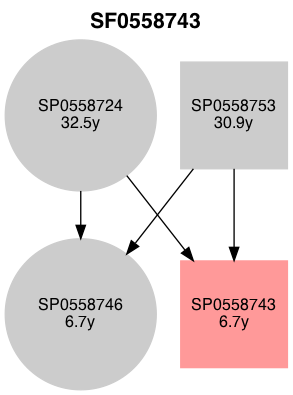

In [183]:
G, roles = family_to_graph_with_roles(metadata, sfid="SF0558743")
plot_family_graphviz(G, role_map=roles, title = "SF0558743")


,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
108790,SP0422593,SF0422501,0,0,Male,False,556.0,WES5,2022-03-31,0.071,1.65036846414785,96.5851,TwistGxS,5.0,nan,False,False,11
108791,SP0422508,SF0422501,SP0422593,SP0422500,Male,False,100.0,WES5,2022-03-30,0.049,1.65049342105263,94.7768,TwistGxS,5.0,SP0422505,False,False,11
108792,SP0422501,SF0422501,SP0422593,SP0422500,Male,True,207.0,WES5,2022-03-31,0.086,1.75602800103708,89.4651,TwistGxS,5.0,nan,False,False,11
108793,SP0422504,SF0422501,SP0422593,SP0422500,Male,True,142.0,WES5,2022-03-30,0.075,1.7625220236597,89.5262,TwistGxS,5.0,nan,False,False,11
108794,SP0422502,SF0422501,SP0422593,SP0422500,Male,True,194.0,WES5,2022-05-16,0.077,1.63202280555886,97.2522,TwistGxS,5.0,nan,False,False,11
108795,SP0422507,SF0422501,SP0422593,SP0422500,Female,False,125.0,WES5,2022-03-30,0.07,1.73332526328532,94.3437,TwistGxS,5.0,nan,False,False,11
108796,SP0422503,SF0422501,SP0422593,SP0422500,Male,True,179.0,WES5,2022-03-30,0.094,1.72,89.2357,TwistGxS,5.0,nan,False,False,11
108797,SP0422510,SF0422501,SP0422593,SP0422500,Female,False,41.0,WES5,2022-05-16,0.387,1.79148884282405,95.8494,TwistGxS,5.0,nan,False,False,11
108798,SP0422505,SF0422501,SP0422593,SP0422500,Male,True,100.0,WES5,2022-03-30,0.074,1.71798704534131,90.3173,TwistGxS,5.0,SP0422508,False,False,11
108799,SP0422509,SF0422501,SP0422593,SP0422500,Female,False,64.0,WES5,2022-03-30,0.048,1.66487935656836,90.7123,TwistGxS,5.0,nan,False,False,11


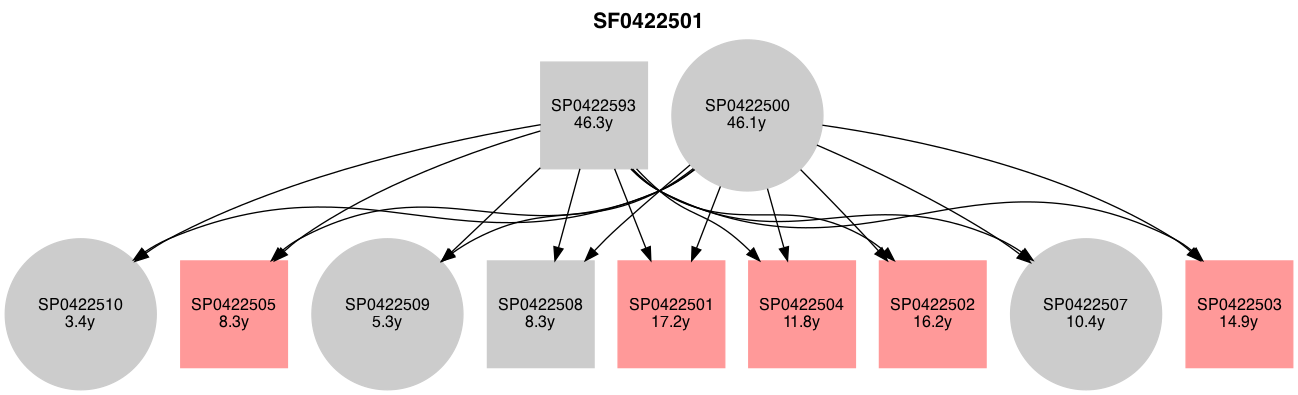

In [179]:
G, roles = family_to_graph_with_roles(metadata, sfid="SF0422501")
plot_family_graphviz(G, role_map=roles, title = "SF0422501")


In [143]:
420 / 12

35.0

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
54420,SP0173717,SF0173718,SP0189510,SP0173716,Female,True,187.0,WES3,2020-08-17,0.068,1.77,96.0,NotAvailable,17.0,nan,False,False,8
54421,SP0173718,SF0173718,0,0,Female,True,97.0,WES9,2023-07-31,0.054,1.71937507397325,96.2628,TwistGxS,17.0,nan,False,False,8
54422,SP0173721,SF0173718,SP0189510,SP0173716,Female,False,175.0,WES5,2022-03-14,0.044,1.72653451158347,96.6904,TwistGxS,17.0,nan,False,False,8
54423,SP0173720,SF0173718,SP0189510,SP0173716,Female,False,187.0,WES5,2022-03-14,0.04,1.78176015711305,96.1213,TwistGxS,17.0,nan,False,False,8
54424,SP0173719,SF0173718,SP0189510,SP0173716,Male,True,100.0,WES3,2020-08-17,0.078,1.64,97.0,NotAvailable,17.0,nan,False,False,8
54425,SP0173722,SF0173718,0,0,Male,False,148.0,WES5,2022-03-14,0.073,1.84541062801932,93.377,TwistGxS,17.0,nan,False,False,8
54426,SP0189510,SF0173718,0,0,Male,False,443.0,WES5,2022-03-16,0.082,1.72853828306265,96.225,TwistGxS,17.0,nan,False,False,8
54427,SP0173716,SF0173718,0,0,Female,False,420.0,WES5,2022-03-14,0.063,1.70742358078603,96.8536,TwistGxS,17.0,nan,False,False,8


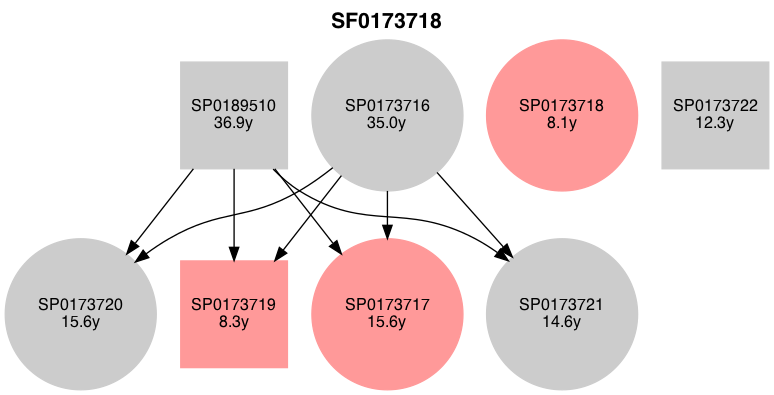

In [187]:
# Multigenerational, maybe an aunt and uncle? but how do I know whose sibling...
G, roles = family_to_graph_with_roles(metadata, sfid="SF0173718")
plot_family_graphviz(G, role_map=roles, title = "SF0173718")

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
107091,SP0415658,SF0415657,0,0,Female,True,101.0,WES5,2022-03-31,0.133,1.67681693826573,96.2233,TwistGxS,1.0,nan,False,False,4
107092,SP0415661,SF0415657,0,0,Female,False,73.0,WES5,2022-03-31,0.065,1.72438500119417,96.2951,TwistGxS,1.0,nan,False,False,4
107093,SP0415657,SF0415657,0,0,Male,True,87.0,WES5,2022-03-31,0.052,1.65611278021724,96.5689,TwistGxS,1.0,nan,False,False,4
107094,SP0415662,SF0415657,0,0,Female,True,60.0,WES5,2022-03-31,0.083,1.70254957507082,95.7903,TwistGxS,1.0,nan,False,False,4


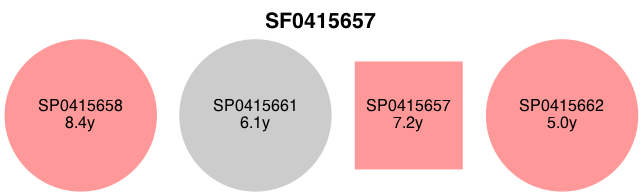

In [188]:
# Single generation, 4 siblings?, no parents recorded
G, roles = family_to_graph_with_roles(metadata, sfid="SF0415657")
plot_family_graphviz(G, role_map=roles, title = "SF0415657")

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
4028,SP0012234,SF0012172,0,SP0012206,Female,False,444.0,WES5,2022-03-30,0.141,1.78089955384059,96.4309,TwistGxS,4.0,nan,False,False,4
4029,SP0012206,SF0012172,0,0,Female,False,690.0,WES5,2022-03-16,0.095,1.61630611770179,96.3205,TwistGxS,4.0,nan,False,False,4
4030,SP0012172,SF0012172,0,SP0011930,Male,True,123.0,WES2,2019-11-07,0.069,1.71,97.0,GSA-v2,4.0,nan,False,False,4
4031,SP0011930,SF0012172,0,SP0012206,Female,True,448.0,WES2,2019-12-17,0.118,1.7,98.0,GSA-v2,4.0,nan,False,False,4


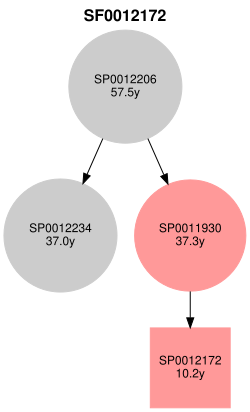

In [161]:
# Grandparents
G, roles = family_to_graph_with_roles(metadata, sfid="SF0012172")
plot_family_graphviz(G, role_map=roles, title = "SF0012172")

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
4684,SP0046500,SF0013826,0,0,Male,False,526.0,WES1,2018-06-21,0.052,1.88,89.0,GSA-v1,2.0,nan,False,False,4
4685,SP0013956,SF0013826,SP0046500,SP0013696,Male,False,62.0,WES1,2018-06-21,0.054,1.85,93.0,GSA-v1,2.0,nan,False,False,4
4686,SP0013696,SF0013826,SP0042347,0,Female,False,535.0,WES1,2018-06-21,0.047,1.95,92.0,GSA-v1,2.0,nan,False,False,4
4687,SP0013826,SF0013826,SP0046500,SP0013696,Male,True,62.0,WES1,2018-06-21,0.169,1.9,95.0,GSA-v1,2.0,nan,False,False,4


None


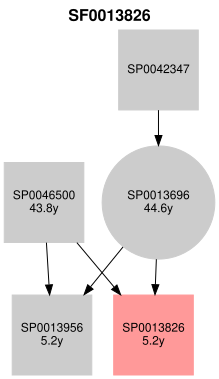

In [163]:
# Grandparents
G, roles = family_to_graph_with_roles(metadata, sfid="SF0013826")
plot_family_graphviz(G, role_map=roles, title = "SF0013826")

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
37521,SP0259681,SF0110558,0,0,Female,False,735.0,WES3,2020-07-23,0.061,1.79,98.0,GSA-v2,2.0,nan,False,False,8
37522,SP0259340,SF0110558,0,0,Male,False,443.0,WES3,2020-08-18,0.117,1.64,96.0,GSA-v2,2.0,nan,False,False,8
37523,SP0110560,SF0110558,SP0259340,SP0110557,Male,True,35.0,WES3,2020-08-18,0.293,1.69,94.0,GSA-v2,2.0,nan,False,False,8
37524,SP0259691,SF0110558,0,0,Male,False,755.0,WES3,2020-07-23,0.043,1.7,98.0,GSA-v2,2.0,nan,False,False,8
37525,SP0110559,SF0110558,SP0259340,SP0110557,Male,True,63.0,WES3,2020-08-18,1.316,1.73,89.0,GSA-v2,2.0,nan,False,False,8
37526,SP0110558,SF0110558,SP0259340,SP0110557,Female,True,96.0,WES3,2020-08-18,0.144,1.71,88.0,GSA-v2,2.0,nan,False,False,8
37527,SP0257553,SF0110558,SP0259691,SP0259681,Male,False,469.0,WES5,2022-03-14,0.068,1.70344501006274,97.0051,TwistGxS,2.0,nan,False,False,8
37528,SP0110557,SF0110558,SP0259691,SP0259681,Female,True,440.0,WES3,2020-08-18,0.121,1.74,97.0,GSA-v2,2.0,nan,False,False,8


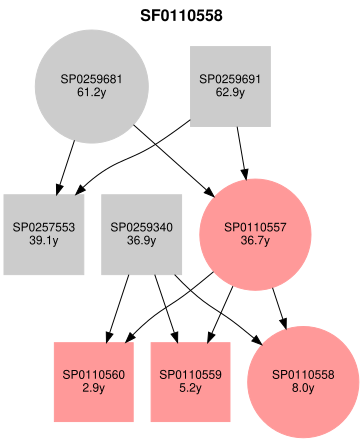

In [164]:
# Grandparents
G, roles = family_to_graph_with_roles(metadata, sfid="SF0110558")
plot_family_graphviz(G, role_map=roles, title = "SF0110558")

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
113737,SP0449352,SF0440105,SP0449408,SP0449415,Female,False,422.0,WES7,2022-11-21,0.077,1.65513985601322,96.0062,TwistGxS,5.0,nan,False,False,8
113738,SP0440105,SF0440105,SP0449343,SP0440104,Male,True,80.0,WES5,2022-03-23,0.048,1.97700385484514,89.726,TwistGxS,5.0,nan,False,False,8
113739,SP0449408,SF0440105,0,0,Male,False,760.0,WES6,2022-08-25,0.064,1.62655115897916,96.5441,TwistGxS,5.0,nan,False,False,8
113740,SP0440110,SF0440105,SP0449343,SP0440104,Male,False,32.0,WES5,2022-03-25,0.061,2.0343163538874,88.7801,TwistGxS,5.0,nan,False,False,8
113741,SP0449343,SF0440105,SP0449408,SP0449415,Male,True,451.0,WES5,2022-03-25,0.056,1.72502413127413,95.0469,TwistGxS,5.0,nan,False,False,8
113742,SP0440104,SF0440105,0,0,Female,False,436.0,WES5,2022-03-25,0.053,1.46980728051392,96.4906,TwistGxS,5.0,nan,False,False,8
113743,SP0440107,SF0440105,SP0449343,SP0440104,Female,True,32.0,WES5,2022-05-16,0.089,1.87859230394545,96.9739,TwistGxS,5.0,nan,False,False,8
113744,SP0449415,SF0440105,0,0,Female,False,729.0,WES6,2022-08-25,0.073,1.81529919802591,96.9665,TwistGxS,5.0,nan,False,False,8


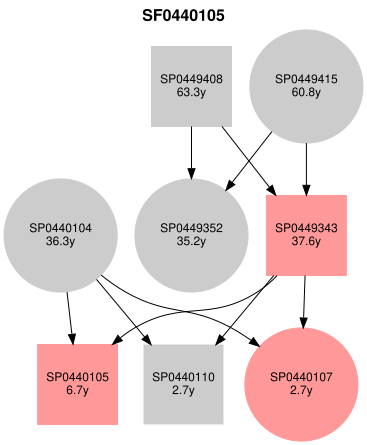

In [166]:
# Grandparents
G, roles = family_to_graph_with_roles(metadata, sfid="SF0440105")
plot_family_graphviz(G, role_map=roles, title = "SF0440105")

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
104037,SP0405304,SF0405306,0,0,Female,False,445.0,WES5,2022-03-23,0.073,1.75509465814542,94.4098,TwistGxS,0.0,nan,False,False,7
104038,SP0555392,SF0405306,0,0,Male,False,480.0,WES9,2023-09-14,0.095,1.74553571428571,96.247,TwistGxS,0.0,nan,False,False,7
104039,SP0405307,SF0405306,SP0555392,SP0405304,Male,True,211.0,WES5,2022-03-28,0.059,1.69910461828464,96.9543,TwistGxS,0.0,nan,False,False,7
104040,SP0405309,SF0405306,SP0405829,SP0405304,Female,False,86.0,WES5,2022-03-28,0.087,1.83525617169086,95.1519,TwistGxS,0.0,nan,False,False,7
104041,SP0405306,SF0405306,SP0405829,SP0405304,Male,True,122.0,WES5,2022-03-28,0.106,1.73615948120572,96.3707,TwistGxS,0.0,nan,False,False,7
104042,SP0555387,SF0405306,0,0,Female,False,469.0,WES9,2023-09-14,0.151,1.81717311814399,95.7804,TwistGxS,0.0,nan,False,False,7
104043,SP0555388,SF0405306,SP0555392,SP0555387,Male,True,130.0,WES9,2023-09-14,0.539,1.81637779452399,96.0246,TwistGxS,0.0,nan,False,False,7


None


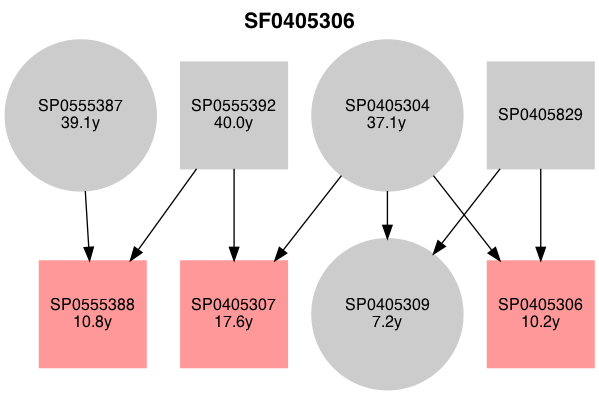

In [186]:
# Parent with multiple partners
G, roles = family_to_graph_with_roles(metadata, sfid="SF0405306")
plot_family_graphviz(G, role_map=roles, title="SF0405306")

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
8236,SP0308494,SF0023920,0,0,Male,False,718.0,WES9,2023-09-14,0.055,1.65158895847831,96.8255,TwistGxS,16.0,nan,False,False,6
8237,SP0024885,SF0023920,0,0,Male,False,539.0,WES1,2018-07-17,0.148,1.73,92.0,GSA-v1,16.0,nan,False,False,6
8238,SP0023951,SF0023920,SP0308494,SP0023897,Male,True,250.0,WES1,2018-08-16,0.065,1.69,97.0,GSA-v1,16.0,nan,False,False,6
8239,SP0023920,SF0023920,SP0024885,SP0023897,Male,True,96.0,WES1,2018-07-17,0.058,1.71,89.0,GSA-v1,16.0,nan,False,False,6
8240,SP0023973,SF0023920,SP0024885,SP0023897,Female,False,71.0,WES1,2018-09-11,0.041,1.81,99.0,GSA-v1,16.0,nan,False,False,6
8241,SP0023897,SF0023920,0,0,Female,False,525.0,WES1,2018-07-17,0.084,1.75,95.0,GSA-v1,16.0,nan,False,False,6


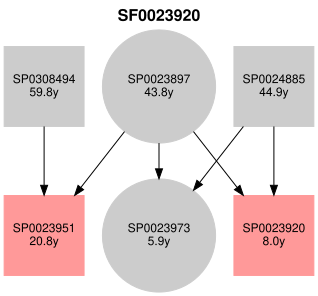

In [168]:
# Parent with multiple partners
G, roles = family_to_graph_with_roles(metadata, sfid="SF0023920")
plot_family_graphviz(G, role_map=roles, title="SF0023920")

In [152]:
metadata[metadata["sfid"] == "SF0444440"]

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
115038,SP0548749,SF0444440,SP0444439,SP0549015,Female,True,103.0,WES9,2023-10-06,0.104,1.776494,96.1497,TwistGxS,2.0,NaN,False,False,8
115039,SP0548750,SF0444440,SP0444439,SP0549015,Male,True,56.0,WES9,2023-09-13,0.088,1.740929,95.5578,TwistGxS,2.0,NaN,False,False,8
115040,SP0444442,SF0444440,SP0444439,SP0549015,Male,True,54.0,WES9,2023-10-06,0.148,1.760278,95.1714,TwistGxS,2.0,NaN,False,False,8
115041,SP0548746,SF0444440,SP0444439,SP0549015,Male,True,185.0,WES9,2023-10-06,0.084,1.754924,96.1248,TwistGxS,2.0,NaN,False,False,8
115042,SP0548748,SF0444440,SP0444439,SP0549015,Male,True,124.0,WES9,2023-09-13,0.079,1.701729,95.4774,TwistGxS,2.0,NaN,False,False,8
115043,SP0549015,SF0444440,0,0,Female,True,470.0,WES9,2023-09-13,0.078,1.798173,96.0028,TwistGxS,2.0,NaN,False,False,8
115044,SP0444441,SF0444440,SP0444439,SP0549015,Female,True,117.0,WES9,2023-09-14,0.074,1.732614,96.5109,TwistGxS,2.0,NaN,False,False,8
115045,SP0548747,SF0444440,SP0444439,SP0549015,Female,True,164.0,WES9,2023-10-06,0.079,1.777764,96.7232,TwistGxS,2.0,NaN,False,False,8


,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
115038,SP0548749,SF0444440,SP0444439,SP0549015,Female,True,103.0,WES9,2023-10-06,0.104,1.77649373002213,96.1497,TwistGxS,2.0,nan,False,False,8
115039,SP0548750,SF0444440,SP0444439,SP0549015,Male,True,56.0,WES9,2023-09-13,0.088,1.74092888243832,95.5578,TwistGxS,2.0,nan,False,False,8
115040,SP0444442,SF0444440,SP0444439,SP0549015,Male,True,54.0,WES9,2023-10-06,0.148,1.76027822630729,95.1714,TwistGxS,2.0,nan,False,False,8
115041,SP0548746,SF0444440,SP0444439,SP0549015,Male,True,185.0,WES9,2023-10-06,0.084,1.75492368291482,96.1248,TwistGxS,2.0,nan,False,False,8
115042,SP0548748,SF0444440,SP0444439,SP0549015,Male,True,124.0,WES9,2023-09-13,0.079,1.70172893241446,95.4774,TwistGxS,2.0,nan,False,False,8
115043,SP0549015,SF0444440,0,0,Female,True,470.0,WES9,2023-09-13,0.078,1.7981730650537,96.0028,TwistGxS,2.0,nan,False,False,8
115044,SP0444441,SF0444440,SP0444439,SP0549015,Female,True,117.0,WES9,2023-09-14,0.074,1.7326139088729,96.5109,TwistGxS,2.0,nan,False,False,8
115045,SP0548747,SF0444440,SP0444439,SP0549015,Female,True,164.0,WES9,2023-10-06,0.079,1.77776406712734,96.7232,TwistGxS,2.0,nan,False,False,8


None


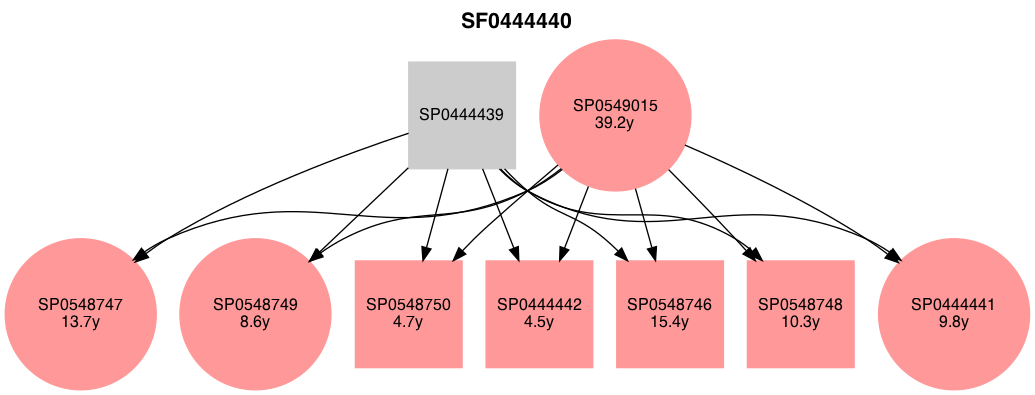

In [184]:
# One parent with ASD
G, roles = family_to_graph_with_roles(metadata, sfid="SF0444440")
plot_family_graphviz(G, role_map=roles, title="SF0444440")

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
132438,SP0510996,SF0510994,SP0511015,SP0510993,Female,True,91.0,WES9,2023-06-30,0.048,1.92227294569918,95.2101,TwistGxS,10.0,nan,False,False,8
132439,SP0531343,SF0510994,0,0,Male,False,909.0,WES9,2023-09-13,0.093,1.72946372239748,88.8824,TwistGxS,10.0,nan,False,False,8
132440,SP0510993,SF0510994,SP0531343,SP0531436,Female,True,427.0,WES9,2023-06-30,0.051,1.73943911963081,95.6876,TwistGxS,10.0,nan,False,False,8
132441,SP0515462,SF0510994,SP0531343,SP0531436,Male,False,407.0,WES9,2023-06-30,0.093,1.68973429951691,93.9361,TwistGxS,10.0,nan,False,False,8
132442,SP0531436,SF0510994,0,0,Female,False,892.0,WES9,2023-09-13,0.07,1.7723606596846,95.3176,TwistGxS,10.0,nan,False,False,8
132443,SP0511015,SF0510994,0,0,Male,True,457.0,WES9,2023-06-30,0.071,1.93957811941366,95.3,TwistGxS,10.0,nan,False,False,8
132444,SP0510997,SF0510994,SP0511015,SP0510993,Male,True,28.0,WES9,2023-06-30,0.071,1.86635670004769,94.669,TwistGxS,10.0,nan,False,False,8
132445,SP0510994,SF0510994,SP0511015,SP0510993,Female,True,132.0,WES9,2023-06-30,0.077,1.99726809884515,94.5772,TwistGxS,10.0,nan,False,False,8


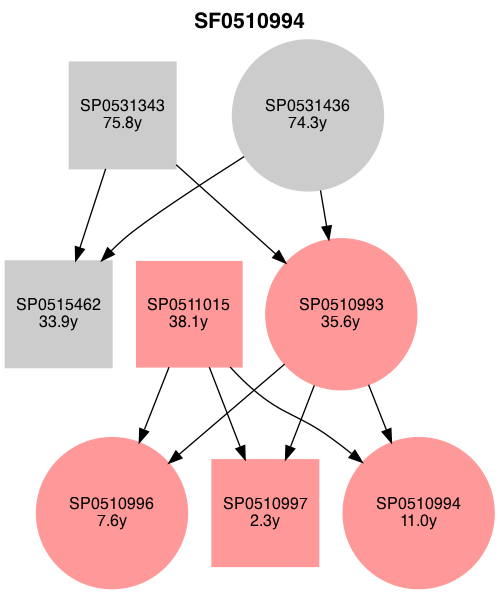

In [185]:
G, roles = family_to_graph_with_roles(metadata, sfid="SF0510994")
plot_family_graphviz(G, role_map=roles, title="SF0510994")

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
142352,SP0318144,SF0583492,0,0,Male,True,192.0,WES3,2020-08-24,0.069,1.73,98.0,GSA-v2,12.0,nan,False,False,5
142353,SP0318143,SF0583492,SP0325663,SP0318140,Male,True,223.0,WES3,2020-08-24,0.055,1.7,98.0,GSA-v2,12.0,nan,False,False,5
142354,SP0329625,SF0583492,SP0325663,SP0318140,Male,True,247.0,WES3,2020-08-25,0.041,1.7,88.0,GSA-v2,12.0,nan,False,False,5
142355,SP0318140,SF0583492,0,0,Female,False,535.0,WES5,2022-03-23,0.069,1.75352617738465,96.7253,TwistGxS,12.0,nan,False,False,5
142356,SP0325663,SF0583492,0,0,Male,False,603.0,WES5,2022-03-16,0.044,1.70273512476008,93.8763,TwistGxS,12.0,nan,False,False,5


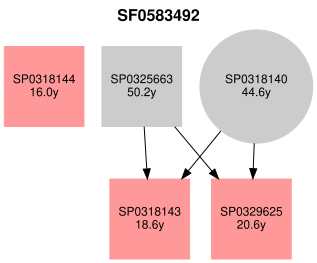

In [171]:
# Adopted children?
G, roles = family_to_graph_with_roles(metadata, sfid="SF0583492")
plot_family_graphviz(G, role_map=roles, title="SF0583492")

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
9942,SP0028277,SF0028553,0,0,Male,False,907.0,WES9,2023-07-31,0.058,1.63077457450504,96.6676,TwistGxS,5.0,nan,False,False,6
9943,SP0028553,SF0028553,SP0028662,SP0028528,Male,True,49.0,WES1,2018-08-06,0.061,1.65,96.0,GSA-v1,5.0,nan,False,False,6
9944,SP0028528,SF0028553,SP0028277,SP0028365,Female,True,334.0,WES1,2018-08-15,0.16,1.69,95.0,GSA-v1,5.0,nan,False,False,6
9945,SP0029050,SF0028553,SP0028277,SP0028365,Male,False,306.0,WES5,2022-02-23,0.116,1.79550451991204,96.5142,TwistGxS,5.0,nan,False,False,6
9946,SP0028365,SF0028553,0,0,Female,False,731.0,WES9,2023-08-03,0.054,1.80437992125984,95.1021,TwistGxS,5.0,nan,False,False,6
9947,SP0028662,SF0028553,0,0,Male,False,350.0,WES1,2018-08-15,0.149,1.68,92.0,GSA-v1,5.0,nan,False,False,6


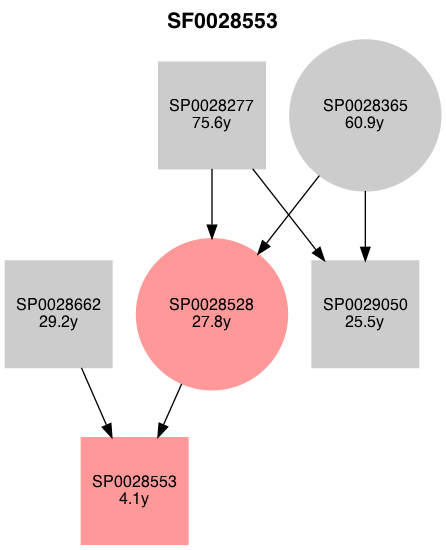

In [190]:
# Adopted children?
G, roles = family_to_graph_with_roles(metadata, sfid="SF0028553")
plot_family_graphviz(G, role_map=roles, title="SF0028553")


In [155]:
metadata[(metadata["mother"] == "0") & (metadata["father"] == "0") & (metadata["asd"] == True)].sort_values(by  = 'family size')

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
2,SP0000017,SF0000017,0,0,Male,True,611.0,WES2,2019-11-26,0.179,1.650000,95.0000,GSA-v2,17.0,NaN,False,False,1
110246,SP0428107,SF0428107,0,0,Female,True,271.0,WES5,2022-03-23,0.093,1.730788,96.8450,TwistGxS,13.0,NaN,False,False,1
110212,SP0427928,SF0427928,0,0,Female,True,466.0,WES5,2022-03-17,0.067,1.837263,90.7782,TwistGxS,14.0,NaN,False,False,1
110197,SP0427905,SF0427905,0,0,Male,True,135.0,WES5,2022-04-06,0.077,2.227444,89.7784,TwistGxS,9.0,NaN,False,False,1
110196,SP0427897,SF0427897,0,0,Female,True,350.0,WES5,2022-03-16,0.071,1.784676,96.3279,TwistGxS,1.0,NaN,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115043,SP0549015,SF0444440,0,0,Female,True,470.0,WES9,2023-09-13,0.078,1.798173,96.0028,TwistGxS,2.0,NaN,False,False,8
54421,SP0173718,SF0173718,0,0,Female,True,97.0,WES9,2023-07-31,0.054,1.719375,96.2628,TwistGxS,17.0,NaN,False,False,8
80111,SP0305379,SF0305128,0,0,Female,True,437.0,WES3,2020-08-18,0.042,1.700000,91.0000,GSA-v2,10.0,NaN,False,False,8
22683,SP0063735,SF0063733,0,0,Male,True,90.0,WES3,2020-09-03,0.047,1.620000,98.0000,GSA-v2,15.0,NaN,False,False,8


In [ ]:
parents_possible = metadata[(metadata["father"] == "0") & (metadata["mother"] == "0")]
parents_possible.groupby('sfid').sum('asd')

,asd,age_m,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,xhmm_batch,in_spark_wgs,in_searchlight,family size
sfid,,,,,,,,,
SF0000003,0,369.0,0.055,2.410000,97.0000,3.0,0,0,2
SF0000017,1,611.0,0.179,1.650000,95.0000,17.0,0,0,1
SF0000026,0,522.0,0.132,1.815472,95.3584,8.0,0,0,3
SF0000027,0,1047.0,0.164,3.460000,189.0000,18.0,0,0,10
SF0000030,0,469.0,0.057,1.800000,90.0000,12.0,0,0,2
...,...,...,...,...,...,...,...,...,...
SF0566626,0,729.0,0.133,3.411348,193.3161,8.0,0,0,6
SF0568275,1,350.0,0.095,1.805248,95.7322,15.0,0,0,1
SF0571246,0,533.0,0.068,1.869703,80.8078,16.0,0,0,2


In [ ]:
# Build a parent-child mapping
parent_map = {}
for _, row in metadata.iterrows():
    child = row["spid"]
    parents = [p for p in [row["father"], row["mother"]] if p not in [None, "0", "NA"]]
    parent_map[child] = parents

# Recursive function to compute depth
def pedigree_depth(individual):
    if individual not in parent_map or not parent_map[individual]:
        return 1
    return 1 + max(pedigree_depth(p) for p in parent_map[individual])

# Compute max depth per family
family_depths = {}
for sfid, fam in metadata.groupby("sfid"):
    max_depth = max(pedigree_depth(ind) for ind in fam["spid"])
    family_depths[sfid] = max_depth

# Select multigenerational families (depth > 2)
multigen_families = [sfid for sfid, depth in family_depths.items() if depth > 2]
# I checked and there are no 4 generation trees
print("Multigenerational families:", multigen_families)

Multigenerational families: ['SF0012172', 'SF0013826', 'SF0013906', 'SF0015857', 'SF0016190', 'SF0016862', 'SF0017006', 'SF0018447', 'SF0019346', 'SF0019606', 'SF0020986', 'SF0022854', 'SF0023652', 'SF0023693', 'SF0028553', 'SF0030399', 'SF0030574', 'SF0041840', 'SF0047603', 'SF0053379', 'SF0055649', 'SF0066218', 'SF0066587', 'SF0070264', 'SF0081054', 'SF0087629', 'SF0090140', 'SF0092177', 'SF0093963', 'SF0096345', 'SF0099211', 'SF0102884', 'SF0110558', 'SF0110759', 'SF0116438', 'SF0117617', 'SF0130074', 'SF0164905', 'SF0166107', 'SF0168683', 'SF0170288', 'SF0187652', 'SF0189888', 'SF0192980', 'SF0200803', 'SF0200877', 'SF0205184', 'SF0217265', 'SF0219549', 'SF0225804', 'SF0225874', 'SF0226253', 'SF0233301', 'SF0234817', 'SF0240296', 'SF0251951', 'SF0256495', 'SF0262021', 'SF0266650', 'SF0289945', 'SF0292057', 'SF0297313', 'SF0298586', 'SF0300835', 'SF0301871', 'SF0306948', 'SF0311949', 'SF0313378', 'SF0324996', 'SF0326457', 'SF0333617', 'SF0337892', 'SF0340941', 'SF0345107', 'SF034545

In [89]:
len(multigen_families)

138

In [90]:
metadata[metadata["sfid"].isin(multigen_families)].sort_values(by = 'family size')

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
32415,SP0098028,SF0092177,0,SP0092176,Female,True,440.0,WES1,2018-08-20,0.080,1.690000,97.0000,GSA-v1,17.0,NaN,False,False,2
83597,SP0324995,SF0324996,0,SP0329097,Female,True,468.0,WES4,2021-05-04,0.240,1.730000,97.0000,GSA-v2,6.0,NaN,False,False,2
83598,SP0324996,SF0324996,0,SP0324995,Male,True,181.0,WES4,2021-05-04,0.073,1.630000,98.0000,GSA-v2,6.0,NaN,False,False,2
6727,SP0019617,SF0019606,0,SP0019510,Male,True,149.0,WES5,2022-03-21,0.051,1.654052,96.6624,TwistGxS,4.0,NaN,False,False,2
6728,SP0019510,SF0019606,SP0022704,0,Female,True,640.0,WES5,2022-03-21,0.048,1.721639,96.8053,TwistGxS,4.0,NaN,False,False,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37521,SP0259681,SF0110558,0,0,Female,False,735.0,WES3,2020-07-23,0.061,1.790000,98.0000,GSA-v2,2.0,NaN,False,False,8
37522,SP0259340,SF0110558,0,0,Male,False,443.0,WES3,2020-08-18,0.117,1.640000,96.0000,GSA-v2,2.0,NaN,False,False,8
37527,SP0257553,SF0110558,SP0259691,SP0259681,Male,False,469.0,WES5,2022-03-14,0.068,1.703445,97.0051,TwistGxS,2.0,NaN,False,False,8
113744,SP0449415,SF0440105,0,0,Female,False,729.0,WES6,2022-08-25,0.073,1.815299,96.9665,TwistGxS,5.0,NaN,False,False,8


In [111]:
# Remove rows where father or mother is "0"
valid_parents = metadata[(metadata['father'] != "0") & (metadata['mother'] != "0")]

# Get unique parent pairs
unique_parent_pairs = valid_parents[['father', 'mother']].drop_duplicates()
unique_parent_pairs.groupby('father').count().sort_values(by = 'mother')

,mother
father,
SP0000006,1
SP0377869,1
SP0377867,1
SP0377865,1
SP0377862,1
...,...
SP0016512,2
SP0252326,2
SP0220562,2


In [115]:
unique_parent_pairs.groupby('mother').count().sort_values(by = 'father')

,father
mother,
SP0000046,1
SP0368313,1
SP0368297,1
SP0368275,1
SP0368267,1
...,...
SP0081602,2
SP0297819,2
SP0030195,2


In [117]:
metadata[metadata['spid'] == 'SP0023897']

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
8241,SP0023897,SF0023920,0,0,Female,False,525.0,WES1,2018-07-17,0.084,1.75,95.0,GSA-v1,16.0,NaN,False,False,6


In [118]:
metadata[metadata['sfid'] == 'SF0023920']

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
8236,SP0308494,SF0023920,0,0,Male,False,718.0,WES9,2023-09-14,0.055,1.651589,96.8255,TwistGxS,16.0,NaN,False,False,6
8237,SP0024885,SF0023920,0,0,Male,False,539.0,WES1,2018-07-17,0.148,1.730000,92.0000,GSA-v1,16.0,NaN,False,False,6
8238,SP0023951,SF0023920,SP0308494,SP0023897,Male,True,250.0,WES1,2018-08-16,0.065,1.690000,97.0000,GSA-v1,16.0,NaN,False,False,6
8239,SP0023920,SF0023920,SP0024885,SP0023897,Male,True,96.0,WES1,2018-07-17,0.058,1.710000,89.0000,GSA-v1,16.0,NaN,False,False,6
8240,SP0023973,SF0023920,SP0024885,SP0023897,Female,False,71.0,WES1,2018-09-11,0.041,1.810000,99.0000,GSA-v1,16.0,NaN,False,False,6
8241,SP0023897,SF0023920,0,0,Female,False,525.0,WES1,2018-07-17,0.084,1.750000,95.0000,GSA-v1,16.0,NaN,False,False,6


In [98]:
# Group by father and count unique mothers
father_partners = metadata.groupby("father")["mother"].nunique()
fathers_multiple_partners = father_partners[father_partners > 1].index.tolist()
print("Fathers with multiple partners:", fathers_multiple_partners)

# Group by mother and count unique fathers
mother_partners = metadata.groupby("mother")["father"].nunique()
mothers_multiple_partners = mother_partners[mother_partners > 1].index.tolist()
print("Mothers with multiple partners:", mothers_multiple_partners)

# Pull out families where a parent has multiple partners
multi_partner_families = metadata[
    metadata["father"].isin(fathers_multiple_partners) |
    metadata["mother"].isin(mothers_multiple_partners)
]
print("Families with multi-partner parent:")
multi_partner_families

Fathers with multiple partners: ['0', 'SP0013098', 'SP0015104', 'SP0016512', 'SP0020173', 'SP0034371', 'SP0043408', 'SP0044122', 'SP0066697', 'SP0068191', 'SP0069290', 'SP0086534', 'SP0095936', 'SP0098354', 'SP0110385', 'SP0110599', 'SP0120119', 'SP0151220', 'SP0160934', 'SP0161492', 'SP0164766', 'SP0172862', 'SP0190631', 'SP0198558', 'SP0199206', 'SP0205224', 'SP0220562', 'SP0223941', 'SP0228809', 'SP0242938', 'SP0252326', 'SP0255717', 'SP0273357', 'SP0312718', 'SP0324696', 'SP0340508', 'SP0345090', 'SP0358696', 'SP0372941', 'SP0390942', 'SP0463894', 'SP0468579', 'SP0507589', 'SP0521898', 'SP0555392']
Mothers with multiple partners: ['0', 'SP0003738', 'SP0004265', 'SP0004615', 'SP0005092', 'SP0008255', 'SP0011140', 'SP0012513', 'SP0014264', 'SP0014326', 'SP0016472', 'SP0020995', 'SP0021574', 'SP0023897', 'SP0024060', 'SP0025111', 'SP0027112', 'SP0030195', 'SP0030836', 'SP0030923', 'SP0031718', 'SP0031775', 'SP0032285', 'SP0042619', 'SP0047121', 'SP0048580', 'SP0052284', 'SP0052474', '

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
0,SP0000003,SF0000003,0,SP0000002,Male,True,123.0,WES1,2018-07-27,0.111,2.070000,90.0000,GSA-v1,3.0,NaN,False,False,2
1,SP0000002,SF0000003,0,0,Female,False,369.0,WES1,2018-08-29,0.055,2.410000,97.0000,GSA-v1,3.0,NaN,False,False,2
2,SP0000017,SF0000017,0,0,Male,True,611.0,WES2,2019-11-26,0.179,1.650000,95.0000,GSA-v2,17.0,NaN,False,False,1
4,SP0000046,SF0000026,0,0,Female,False,522.0,WES6,2022-09-12,0.132,1.815472,95.3584,TwistGxS,8.0,NaN,False,False,3
6,SP0000051,SF0000027,0,0,Female,False,530.0,WES1,2018-06-26,0.047,1.750000,94.0000,GSA-v1,9.0,NaN,False,False,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142350,SP0371087,SF0572144,0,0,Female,False,661.0,WES5,2022-03-21,0.061,1.827904,88.4050,TwistGxS,14.0,NaN,False,False,2
142351,SP0360833,SF0572144,0,SP0371087,Female,True,347.0,WES4,2021-05-05,0.067,1.730000,98.0000,GSA-v2,14.0,NaN,False,False,2
142352,SP0318144,SF0583492,0,0,Male,True,192.0,WES3,2020-08-24,0.069,1.730000,98.0000,GSA-v2,12.0,NaN,False,False,5
142355,SP0318140,SF0583492,0,0,Female,False,535.0,WES5,2022-03-23,0.069,1.753526,96.7253,TwistGxS,12.0,NaN,False,False,5


In [76]:
metadata[metadata['sfid'] == "SF0173718"]

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
54420,SP0173717,SF0173718,SP0189510,SP0173716,Female,True,187.0,WES3,2020-08-17,0.068,1.770000,96.0000,NotAvailable,17.0,NaN,False,False,8
54421,SP0173718,SF0173718,0,0,Female,True,97.0,WES9,2023-07-31,0.054,1.719375,96.2628,TwistGxS,17.0,NaN,False,False,8
54422,SP0173721,SF0173718,SP0189510,SP0173716,Female,False,175.0,WES5,2022-03-14,0.044,1.726535,96.6904,TwistGxS,17.0,NaN,False,False,8
54423,SP0173720,SF0173718,SP0189510,SP0173716,Female,False,187.0,WES5,2022-03-14,0.040,1.781760,96.1213,TwistGxS,17.0,NaN,False,False,8
54424,SP0173719,SF0173718,SP0189510,SP0173716,Male,True,100.0,WES3,2020-08-17,0.078,1.640000,97.0000,NotAvailable,17.0,NaN,False,False,8
54425,SP0173722,SF0173718,0,0,Male,False,148.0,WES5,2022-03-14,0.073,1.845411,93.3770,TwistGxS,17.0,NaN,False,False,8
54426,SP0189510,SF0173718,0,0,Male,False,443.0,WES5,2022-03-16,0.082,1.728538,96.2250,TwistGxS,17.0,NaN,False,False,8
54427,SP0173716,SF0173718,0,0,Female,False,420.0,WES5,2022-03-14,0.063,1.707424,96.8536,TwistGxS,17.0,NaN,False,False,8


In [79]:
possib_parents = metadata[(metadata["father"] == "0") & (metadata["mother"] == "0")]
possib_parents[possib_parents["sfid"].str[2:] == possib_parents["spid"].str[2:]].sort_values(by = 'family size')[-20:]

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
107093,SP0415657,SF0415657,0,0,Male,True,87.0,WES5,2022-03-31,0.052,1.656113,96.5689,TwistGxS,1.0,NaN,False,False,4
129740,SP0498767,SF0498767,0,0,Male,True,156.0,WES7,2022-12-09,0.062,2.216200,94.7000,TwistGxS,5.0,NaN,False,False,4
52288,SP0164307,SF0164307,0,0,Male,True,66.0,WES3,2020-09-01,0.070,1.700000,96.0000,GSA-v2,3.0,NaN,False,False,4
28217,SP0079676,SF0079676,0,0,Male,True,127.0,WES2,2019-11-25,0.074,1.690000,98.0000,GSA-v2,8.0,NaN,False,False,4
104203,SP0405957,SF0405957,0,0,Male,True,177.0,WES5,2022-03-30,0.079,2.224129,96.9125,TwistGxS,3.0,NaN,False,False,4
70495,SP0258343,SF0258343,0,0,Male,True,90.0,WES3,2020-08-13,0.082,1.830000,97.0000,GSA-v2,7.0,NaN,False,False,4
109285,SP0424435,SF0424435,0,0,Male,True,218.0,WES5,2022-03-28,0.068,1.808829,95.0367,TwistGxS,13.0,NaN,False,False,4
136653,SP0529614,SF0529614,0,0,Male,True,161.0,WES9,2023-07-24,0.062,1.748244,93.5789,TwistGxS,0.0,NaN,False,False,4
14525,SP0041228,SF0041228,0,0,Female,True,168.0,WES2,2019-11-25,0.097,1.730000,96.0000,GSA-v2,8.0,NaN,False,False,4
60809,SP0208855,SF0208855,0,0,Female,True,136.0,WES3,2020-08-17,0.130,1.760000,98.0000,GSA-v2,1.0,NaN,False,False,4


In [21]:
G = family_to_graph(metadata, "SF0422501")
print(G.nodes(data=True))  # nodes with ASD status
print(G.edges())           # parent → child edges


[('SP0422593', {'asd': False}), ('SP0422508', {'asd': 'False'}), ('SP0422500', {'asd': 'False'}), ('SP0422501', {'asd': 'True'}), ('SP0422504', {'asd': 'True'}), ('SP0422502', {'asd': 'True'}), ('SP0422507', {'asd': 'False'}), ('SP0422503', {'asd': 'True'}), ('SP0422510', {'asd': 'False'}), ('SP0422505', {'asd': 'True'}), ('SP0422509', {'asd': 'False'})]
[('SP0422593', 'SP0422508'), ('SP0422593', 'SP0422501'), ('SP0422593', 'SP0422504'), ('SP0422593', 'SP0422502'), ('SP0422593', 'SP0422507'), ('SP0422593', 'SP0422503'), ('SP0422593', 'SP0422510'), ('SP0422593', 'SP0422505'), ('SP0422593', 'SP0422509'), ('SP0422500', 'SP0422508'), ('SP0422500', 'SP0422501'), ('SP0422500', 'SP0422504'), ('SP0422500', 'SP0422502'), ('SP0422500', 'SP0422507'), ('SP0422500', 'SP0422503'), ('SP0422500', 'SP0422510'), ('SP0422500', 'SP0422505'), ('SP0422500', 'SP0422509')]


In [22]:
print_graph_tree(G)

SP0422593 (ASD=False)
    SP0422508 (ASD=False)
    SP0422501 (ASD=True)
    SP0422504 (ASD=True)
    SP0422502 (ASD=True)
    SP0422507 (ASD=False)
    SP0422503 (ASD=True)
    SP0422510 (ASD=False)
    SP0422505 (ASD=True)
    SP0422509 (ASD=False)
SP0422500 (ASD=False)


In [23]:
from graphviz import Digraph


In [25]:
metadata

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
0,SP0000003,SF0000003,0,SP0000002,Male,True,123.0,WES1,2018-07-27,0.111,2.070000,90.0000,GSA-v1,3.0,NaN,False,False,2
1,SP0000002,SF0000003,0,0,Female,False,369.0,WES1,2018-08-29,0.055,2.410000,97.0000,GSA-v1,3.0,NaN,False,False,2
2,SP0000017,SF0000017,0,0,Male,True,611.0,WES2,2019-11-26,0.179,1.650000,95.0000,GSA-v2,17.0,NaN,False,False,1
3,SP0000026,SF0000026,SP0255776,SP0000046,Female,True,65.0,WES6,2022-09-12,0.040,1.721284,95.6968,TwistGxS,8.0,NaN,False,False,3
4,SP0000046,SF0000026,0,0,Female,False,522.0,WES6,2022-09-12,0.132,1.815472,95.3584,TwistGxS,8.0,NaN,False,False,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142352,SP0318144,SF0583492,0,0,Male,True,192.0,WES3,2020-08-24,0.069,1.730000,98.0000,GSA-v2,12.0,NaN,False,False,5
142353,SP0318143,SF0583492,SP0325663,SP0318140,Male,True,223.0,WES3,2020-08-24,0.055,1.700000,98.0000,GSA-v2,12.0,NaN,False,False,5
142354,SP0329625,SF0583492,SP0325663,SP0318140,Male,True,247.0,WES3,2020-08-25,0.041,1.700000,88.0000,GSA-v2,12.0,NaN,False,False,5
142355,SP0318140,SF0583492,0,0,Female,False,535.0,WES5,2022-03-23,0.069,1.753526,96.7253,TwistGxS,12.0,NaN,False,False,5


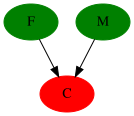

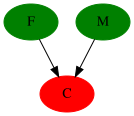

In [ ]:
from graphviz import Digraph
from IPython.display import SVG, display
import pandas as pd

def plot_pedigree(metadata, root_sfid=None):
    """
    Plot a pedigree tree from metadata DataFrame.
    """
    dot = Digraph(comment='Pedigree Tree')
    
    # Add nodes with phenotype coloring
    for _, row in metadata.iterrows():
        color = 'red' if row['ASD']==1 else 'green'
        dot.node(row['sfid'], row['sfid'], color=color, style='filled')
    
    # Add edges (father -> child, mother -> child)
    for _, row in metadata.iterrows():
        if pd.notna(row['father_sfid']):
            dot.edge(row['father_sfid'], row['sfid'])
        if pd.notna(row['mother_sfid']):
            dot.edge(row['mother_sfid'], row['sfid'])
    
    # If you want to focus on a root individual
    # optional: filter by descendants
    display(SVG(dot.pipe(format='svg')))
    return dot

# Plot tree
plot_pedigree(metadata, root_sfid='SF0422501')

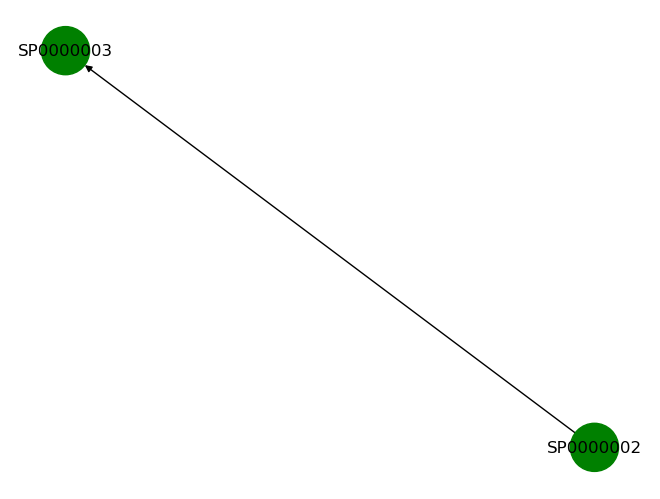

In [ ]:
import matplotlib.pyplot as plt

# Simple layout
pos = nx.spring_layout(G, seed=42)  # fallback layout
node_colors = ["red" if G.nodes[n]["asd"] in [1, True] else "green" for n in G.nodes]

nx.draw(G, pos, with_labels=True, node_size=1200, node_color=node_colors)
plt.show()

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
0,SP0000003,SF0000003,0,SP0000002,Male,True,123.0,WES1,2018-07-27,0.111,2.070000,90.0000,GSA-v1,3.0,NaN,False,False,2
1,SP0000002,SF0000003,0,0,Female,False,369.0,WES1,2018-08-29,0.055,2.410000,97.0000,GSA-v1,3.0,NaN,False,False,2
2,SP0000017,SF0000017,0,0,Male,True,611.0,WES2,2019-11-26,0.179,1.650000,95.0000,GSA-v2,17.0,NaN,False,False,1
3,SP0000026,SF0000026,SP0255776,SP0000046,Female,True,65.0,WES6,2022-09-12,0.040,1.721284,95.6968,TwistGxS,8.0,NaN,False,False,3
4,SP0000046,SF0000026,0,0,Female,False,522.0,WES6,2022-09-12,0.132,1.815472,95.3584,TwistGxS,8.0,NaN,False,False,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142352,SP0318144,SF0583492,0,0,Male,True,192.0,WES3,2020-08-24,0.069,1.730000,98.0000,GSA-v2,12.0,NaN,False,False,5
142353,SP0318143,SF0583492,SP0325663,SP0318140,Male,True,223.0,WES3,2020-08-24,0.055,1.700000,98.0000,GSA-v2,12.0,NaN,False,False,5
142354,SP0329625,SF0583492,SP0325663,SP0318140,Male,True,247.0,WES3,2020-08-25,0.041,1.700000,88.0000,GSA-v2,12.0,NaN,False,False,5
142355,SP0318140,SF0583492,0,0,Female,False,535.0,WES5,2022-03-23,0.069,1.753526,96.7253,TwistGxS,12.0,NaN,False,False,5


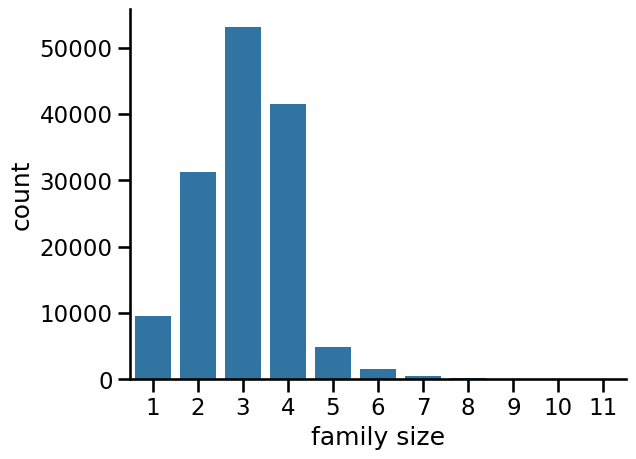

In [6]:
sns.set_context('talk')
sns.barplot(metadata["family size"].value_counts())
sns.despine()

In [7]:
families = metadata[metadata["family size"] >= 2]
families

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
0,SP0000003,SF0000003,0,SP0000002,Male,True,123.0,WES1,2018-07-27,0.111,2.070000,90.0000,GSA-v1,3.0,NaN,False,False,2
1,SP0000002,SF0000003,0,0,Female,False,369.0,WES1,2018-08-29,0.055,2.410000,97.0000,GSA-v1,3.0,NaN,False,False,2
3,SP0000026,SF0000026,SP0255776,SP0000046,Female,True,65.0,WES6,2022-09-12,0.040,1.721284,95.6968,TwistGxS,8.0,NaN,False,False,3
4,SP0000046,SF0000026,0,0,Female,False,522.0,WES6,2022-09-12,0.132,1.815472,95.3584,TwistGxS,8.0,NaN,False,False,3
5,SP0000062,SF0000026,SP0255776,SP0000046,Female,False,65.0,WES6,2022-09-12,0.095,1.715326,96.1490,TwistGxS,8.0,NaN,False,False,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142352,SP0318144,SF0583492,0,0,Male,True,192.0,WES3,2020-08-24,0.069,1.730000,98.0000,GSA-v2,12.0,NaN,False,False,5
142353,SP0318143,SF0583492,SP0325663,SP0318140,Male,True,223.0,WES3,2020-08-24,0.055,1.700000,98.0000,GSA-v2,12.0,NaN,False,False,5
142354,SP0329625,SF0583492,SP0325663,SP0318140,Male,True,247.0,WES3,2020-08-25,0.041,1.700000,88.0000,GSA-v2,12.0,NaN,False,False,5
142355,SP0318140,SF0583492,0,0,Female,False,535.0,WES5,2022-03-23,0.069,1.753526,96.7253,TwistGxS,12.0,NaN,False,False,5


In [ ]:
families["parent count"] = 

In [41]:
metadata[metadata["spid"].str[2:] == metadata["sfid"].str[2:]]

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
0,SP0000003,SF0000003,0,SP0000002,Male,True,123.0,WES1,2018-07-27,0.111,2.070000,90.0000,GSA-v1,3.0,NaN,False,False,2
2,SP0000017,SF0000017,0,0,Male,True,611.0,WES2,2019-11-26,0.179,1.650000,95.0000,GSA-v2,17.0,NaN,False,False,1
3,SP0000026,SF0000026,SP0255776,SP0000046,Female,True,65.0,WES6,2022-09-12,0.040,1.721284,95.6968,TwistGxS,8.0,NaN,False,False,3
7,SP0000027,SF0000027,SP0000241,SP0000051,Male,True,147.0,WES1,2018-07-17,0.808,1.800000,92.0000,GSA-v1,9.0,NaN,False,False,5
11,SP0000030,SF0000030,0,SP0001693,Female,True,91.0,WES1,2018-07-27,0.061,1.700000,93.0000,GSA-v1,12.0,NaN,False,False,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142333,SP0559853,SF0559853,0,0,Male,True,955.0,WES9,2023-10-06,0.057,1.747129,95.5629,TwistGxS,17.0,NaN,False,False,1
142335,SP0560327,SF0560327,SP0561195,SP0560326,Female,True,68.0,WES9,2023-10-06,0.100,1.789791,94.0361,TwistGxS,5.0,NaN,False,False,2
142338,SP0560952,SF0560952,SP0560956,SP0560950,Female,True,58.0,WES9,2023-10-06,0.130,1.673120,95.4601,TwistGxS,0.0,NaN,False,False,3
142339,SP0560958,SF0560958,0,0,Male,True,174.0,WES9,2023-10-06,0.095,2.287851,91.6144,TwistGxS,6.0,NaN,False,False,1


In [44]:
possib_parents = metadata[(metadata['father'] =="0") & (metadata["mother"] == "0")]
possib_parents

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
1,SP0000002,SF0000003,0,0,Female,False,369.0,WES1,2018-08-29,0.055,2.410000,97.0000,GSA-v1,3.0,NaN,False,False,2
2,SP0000017,SF0000017,0,0,Male,True,611.0,WES2,2019-11-26,0.179,1.650000,95.0000,GSA-v2,17.0,NaN,False,False,1
4,SP0000046,SF0000026,0,0,Female,False,522.0,WES6,2022-09-12,0.132,1.815472,95.3584,TwistGxS,8.0,NaN,False,False,3
6,SP0000051,SF0000027,0,0,Female,False,530.0,WES1,2018-06-26,0.047,1.750000,94.0000,GSA-v1,9.0,NaN,False,False,5
10,SP0000241,SF0000027,0,0,Male,False,517.0,WES1,2018-08-02,0.117,1.710000,95.0000,GSA-v1,9.0,NaN,False,False,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142348,SP0424823,SF0571246,0,0,Female,False,533.0,WES5,2022-05-13,0.068,1.869703,80.8078,TwistGxS,16.0,NaN,False,False,2
142350,SP0371087,SF0572144,0,0,Female,False,661.0,WES5,2022-03-21,0.061,1.827904,88.4050,TwistGxS,14.0,NaN,False,False,2
142352,SP0318144,SF0583492,0,0,Male,True,192.0,WES3,2020-08-24,0.069,1.730000,98.0000,GSA-v2,12.0,NaN,False,False,5
142355,SP0318140,SF0583492,0,0,Female,False,535.0,WES5,2022-03-23,0.069,1.753526,96.7253,TwistGxS,12.0,NaN,False,False,5


In [21]:
# Children are not parents to anyone in the dataset
children = metadata[~metadata["spid"].isin(metadata["father"].dropna()) &
                    ~metadata["spid"].isin(metadata["mother"].dropna())]

# Probands: children with ASD
probands = children[children["asd"] == True]

# Siblings: children without asd
siblings = children[(children["sfid"].isin(probands["sfid"])) & (children["asd"] == False)]

# Parents: anyone listed as a father or mother
parents_spids = pd.concat([metadata["father"], metadata["mother"]]).dropna().unique()
parents = metadata[metadata["spid"].isin(parents_spids)]

In [39]:
children

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
0,SP0000003,SF0000003,0,SP0000002,Male,True,123.0,WES1,2018-07-27,0.111,2.070000,90.0000,GSA-v1,3.0,NaN,False,False,2
2,SP0000017,SF0000017,0,0,Male,True,611.0,WES2,2019-11-26,0.179,1.650000,95.0000,GSA-v2,17.0,NaN,False,False,1
3,SP0000026,SF0000026,SP0255776,SP0000046,Female,True,65.0,WES6,2022-09-12,0.040,1.721284,95.6968,TwistGxS,8.0,NaN,False,False,3
5,SP0000062,SF0000026,SP0255776,SP0000046,Female,False,65.0,WES6,2022-09-12,0.095,1.715326,96.1490,TwistGxS,8.0,NaN,False,False,3
7,SP0000027,SF0000027,SP0000241,SP0000051,Male,True,147.0,WES1,2018-07-17,0.808,1.800000,92.0000,GSA-v1,9.0,NaN,False,False,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142349,SP0412142,SF0571246,0,SP0424823,Female,True,338.0,WES5,2022-03-21,0.077,1.758782,96.2742,TwistGxS,16.0,NaN,False,False,2
142351,SP0360833,SF0572144,0,SP0371087,Female,True,347.0,WES4,2021-05-05,0.067,1.730000,98.0000,GSA-v2,14.0,NaN,False,False,2
142352,SP0318144,SF0583492,0,0,Male,True,192.0,WES3,2020-08-24,0.069,1.730000,98.0000,GSA-v2,12.0,NaN,False,False,5
142353,SP0318143,SF0583492,SP0325663,SP0318140,Male,True,223.0,WES3,2020-08-24,0.055,1.700000,98.0000,GSA-v2,12.0,NaN,False,False,5


In [40]:
children = metadata[metadata["father"].isin(metadata["spid"]) | metadata["mother"].isin(metadata["spid"])]
children

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
0,SP0000003,SF0000003,0,SP0000002,Male,True,123.0,WES1,2018-07-27,0.111,2.070000,90.0000,GSA-v1,3.0,NaN,False,False,2
3,SP0000026,SF0000026,SP0255776,SP0000046,Female,True,65.0,WES6,2022-09-12,0.040,1.721284,95.6968,TwistGxS,8.0,NaN,False,False,3
5,SP0000062,SF0000026,SP0255776,SP0000046,Female,False,65.0,WES6,2022-09-12,0.095,1.715326,96.1490,TwistGxS,8.0,NaN,False,False,3
7,SP0000027,SF0000027,SP0000241,SP0000051,Male,True,147.0,WES1,2018-07-17,0.808,1.800000,92.0000,GSA-v1,9.0,NaN,False,False,5
8,SP0000034,SF0000027,SP0000241,SP0000051,Male,True,130.0,WES1,2018-08-17,0.088,1.760000,95.0000,GSA-v1,9.0,NaN,False,False,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142345,SP0411602,SF0566626,SP0411615,SP0411597,Male,True,53.0,WES5,2022-03-23,0.096,1.689680,96.8973,TwistGxS,4.0,NaN,False,False,3
142349,SP0412142,SF0571246,0,SP0424823,Female,True,338.0,WES5,2022-03-21,0.077,1.758782,96.2742,TwistGxS,16.0,NaN,False,False,2
142351,SP0360833,SF0572144,0,SP0371087,Female,True,347.0,WES4,2021-05-05,0.067,1.730000,98.0000,GSA-v2,14.0,NaN,False,False,2
142353,SP0318143,SF0583492,SP0325663,SP0318140,Male,True,223.0,WES3,2020-08-24,0.055,1.700000,98.0000,GSA-v2,12.0,NaN,False,False,5


In [23]:
probands

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
0,SP0000003,SF0000003,0,SP0000002,Male,True,123.0,WES1,2018-07-27,0.111,2.070000,90.0000,GSA-v1,3.0,NaN,False,False,2
2,SP0000017,SF0000017,0,0,Male,True,611.0,WES2,2019-11-26,0.179,1.650000,95.0000,GSA-v2,17.0,NaN,False,False,1
3,SP0000026,SF0000026,SP0255776,SP0000046,Female,True,65.0,WES6,2022-09-12,0.040,1.721284,95.6968,TwistGxS,8.0,NaN,False,False,3
7,SP0000027,SF0000027,SP0000241,SP0000051,Male,True,147.0,WES1,2018-07-17,0.808,1.800000,92.0000,GSA-v1,9.0,NaN,False,False,5
8,SP0000034,SF0000027,SP0000241,SP0000051,Male,True,130.0,WES1,2018-08-17,0.088,1.760000,95.0000,GSA-v1,9.0,NaN,False,False,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142349,SP0412142,SF0571246,0,SP0424823,Female,True,338.0,WES5,2022-03-21,0.077,1.758782,96.2742,TwistGxS,16.0,NaN,False,False,2
142351,SP0360833,SF0572144,0,SP0371087,Female,True,347.0,WES4,2021-05-05,0.067,1.730000,98.0000,GSA-v2,14.0,NaN,False,False,2
142352,SP0318144,SF0583492,0,0,Male,True,192.0,WES3,2020-08-24,0.069,1.730000,98.0000,GSA-v2,12.0,NaN,False,False,5
142353,SP0318143,SF0583492,SP0325663,SP0318140,Male,True,223.0,WES3,2020-08-24,0.055,1.700000,98.0000,GSA-v2,12.0,NaN,False,False,5


In [24]:
siblings

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
5,SP0000062,SF0000026,SP0255776,SP0000046,Female,False,65.0,WES6,2022-09-12,0.095,1.715326,96.1490,TwistGxS,8.0,NaN,False,False,3
13,SP0000036,SF0000033,SP0000684,SP0000067,Male,False,94.0,WES9,2023-09-13,0.056,1.773653,95.0403,TwistGxS,15.0,NaN,False,False,3
38,SP0001673,SF0000145,SP0007039,SP0000111,Male,False,183.0,WES1,2018-07-25,0.058,1.710000,96.0000,GSA-v1,1.0,NaN,False,False,4
50,SP0000201,SF0000164,SP0000231,SP0000131,Male,False,131.0,WES5,2022-05-16,0.044,1.692632,96.8477,TwistGxS,2.0,NaN,False,False,3
56,SP0000208,SF0000173,0,SP0000140,Female,False,109.0,WES5,2022-05-13,0.044,1.522398,97.2512,TwistGxS,11.0,NaN,False,False,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142278,SP0558578,SF0558577,0,SP0558576,Male,False,152.0,WES9,2023-10-06,0.076,1.687634,95.6862,TwistGxS,1.0,NaN,False,False,3
142287,SP0558646,SF0558645,SP0558652,SP0558644,Male,False,185.0,WES9,2023-10-06,0.052,1.778212,93.3366,TwistGxS,15.0,NaN,False,False,5
142291,SP0558735,SF0558734,SP0560038,SP0550207,Female,False,53.0,WES9,2023-10-06,0.079,1.698440,95.9418,TwistGxS,14.0,NaN,False,False,4
142296,SP0558746,SF0558743,SP0558753,SP0558724,Female,False,80.0,WES9,2023-09-14,0.073,2.217016,95.6624,TwistGxS,5.0,NaN,False,False,4


In [37]:
metadata[metadata["spid"] == "SP0302062"]

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
79509,SP0302062,SF0301871,0,0,Male,False,843.0,WES4,2021-04-12,0.063,1.69,96.0,GSA-v2,11.0,NaN,False,False,5


In [38]:
metadata[metadata["sfid"] == "SF0301871"][["spid", "sfid", "father", "mother", "sex"]]

,spid,sfid,father,mother,sex
79509,SP0302062,SF0301871,0,0,Male
79510,SP0301871,SF0301871,SP0301870,SP0301987,Male
79511,SP0301870,SF0301871,SP0302062,SP0302224,Male
79512,SP0301987,SF0301871,0,0,Female
79513,SP0301872,SF0301871,SP0301870,SP0301987,Male


In [26]:
parents[["father", "mother"]].value_counts()

father     mother   
0          0            62991
SP0302062  SP0302224        1
SP0259691  SP0259681        1
SP0264814  0                1
SP0268551  0                1
                        ...  
0          SP0435001        1
           SP0413544        1
           SP0402449        1
           SP0395837        1
SP0580780  SP0580779        1
Name: count, Length: 140, dtype: int64

In [25]:
parents

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight,family size
1,SP0000002,SF0000003,0,0,Female,False,369.0,WES1,2018-08-29,0.055,2.410000,97.0000,GSA-v1,3.0,NaN,False,False,2
4,SP0000046,SF0000026,0,0,Female,False,522.0,WES6,2022-09-12,0.132,1.815472,95.3584,TwistGxS,8.0,NaN,False,False,3
6,SP0000051,SF0000027,0,0,Female,False,530.0,WES1,2018-06-26,0.047,1.750000,94.0000,GSA-v1,9.0,NaN,False,False,5
10,SP0000241,SF0000027,0,0,Male,False,517.0,WES1,2018-08-02,0.117,1.710000,95.0000,GSA-v1,9.0,NaN,False,False,5
12,SP0001693,SF0000030,0,0,Female,False,469.0,WES1,2018-07-27,0.057,1.800000,90.0000,GSA-v1,12.0,NaN,False,False,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142346,SP0411615,SF0566626,0,0,Male,False,352.0,WES5,2022-03-23,0.071,1.694288,96.7898,TwistGxS,4.0,NaN,False,False,3
142348,SP0424823,SF0571246,0,0,Female,False,533.0,WES5,2022-05-13,0.068,1.869703,80.8078,TwistGxS,16.0,NaN,False,False,2
142350,SP0371087,SF0572144,0,0,Female,False,661.0,WES5,2022-03-21,0.061,1.827904,88.4050,TwistGxS,14.0,NaN,False,False,2
142355,SP0318140,SF0583492,0,0,Female,False,535.0,WES5,2022-03-23,0.069,1.753526,96.7253,TwistGxS,12.0,NaN,False,False,5


In [35]:
min(parents["age_m"]) / 12

18.833333333333332

<Axes: xlabel='age_m', ylabel='Count'>

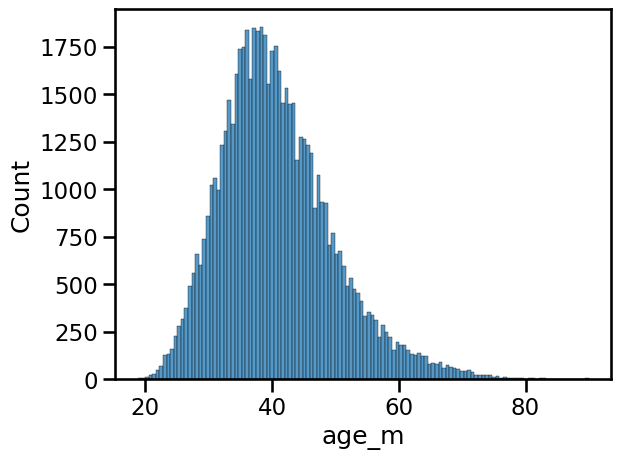

In [32]:
sns.histplot(parents["age_m"] / 12)

In [4]:
asd_affected = metadata[metadata["asd"]]
asd_affected

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight
0,SP0000003,SF0000003,0,SP0000002,Male,True,123.0,WES1,2018-07-27,0.111,2.070000,90.0000,GSA-v1,3.0,NaN,False,False
2,SP0000017,SF0000017,0,0,Male,True,611.0,WES2,2019-11-26,0.179,1.650000,95.0000,GSA-v2,17.0,NaN,False,False
3,SP0000026,SF0000026,SP0255776,SP0000046,Female,True,65.0,WES6,2022-09-12,0.040,1.721284,95.6968,TwistGxS,8.0,NaN,False,False
7,SP0000027,SF0000027,SP0000241,SP0000051,Male,True,147.0,WES1,2018-07-17,0.808,1.800000,92.0000,GSA-v1,9.0,NaN,False,False
8,SP0000034,SF0000027,SP0000241,SP0000051,Male,True,130.0,WES1,2018-08-17,0.088,1.760000,95.0000,GSA-v1,9.0,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142349,SP0412142,SF0571246,0,SP0424823,Female,True,338.0,WES5,2022-03-21,0.077,1.758782,96.2742,TwistGxS,16.0,NaN,False,False
142351,SP0360833,SF0572144,0,SP0371087,Female,True,347.0,WES4,2021-05-05,0.067,1.730000,98.0000,GSA-v2,14.0,NaN,False,False
142352,SP0318144,SF0583492,0,0,Male,True,192.0,WES3,2020-08-24,0.069,1.730000,98.0000,GSA-v2,12.0,NaN,False,False
142353,SP0318143,SF0583492,SP0325663,SP0318140,Male,True,223.0,WES3,2020-08-24,0.055,1.700000,98.0000,GSA-v2,12.0,NaN,False,False


In [5]:
asd_unaffected = metadata[~metadata["asd"]]
asd_unaffected

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight
1,SP0000002,SF0000003,0,0,Female,False,369.0,WES1,2018-08-29,0.055,2.410000,97.0000,GSA-v1,3.0,NaN,False,False
4,SP0000046,SF0000026,0,0,Female,False,522.0,WES6,2022-09-12,0.132,1.815472,95.3584,TwistGxS,8.0,NaN,False,False
5,SP0000062,SF0000026,SP0255776,SP0000046,Female,False,65.0,WES6,2022-09-12,0.095,1.715326,96.1490,TwistGxS,8.0,NaN,False,False
6,SP0000051,SF0000027,0,0,Female,False,530.0,WES1,2018-06-26,0.047,1.750000,94.0000,GSA-v1,9.0,NaN,False,False
10,SP0000241,SF0000027,0,0,Male,False,517.0,WES1,2018-08-02,0.117,1.710000,95.0000,GSA-v1,9.0,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142346,SP0411615,SF0566626,0,0,Male,False,352.0,WES5,2022-03-23,0.071,1.694288,96.7898,TwistGxS,4.0,NaN,False,False
142348,SP0424823,SF0571246,0,0,Female,False,533.0,WES5,2022-05-13,0.068,1.869703,80.8078,TwistGxS,16.0,NaN,False,False
142350,SP0371087,SF0572144,0,0,Female,False,661.0,WES5,2022-03-21,0.061,1.827904,88.4050,TwistGxS,14.0,NaN,False,False
142355,SP0318140,SF0583492,0,0,Female,False,535.0,WES5,2022-03-23,0.069,1.753526,96.7253,TwistGxS,12.0,NaN,False,False


In [6]:
# Approach: Use sfid and parents to merge
# keeps families together, and removes parents (because their recorded parents would be different)
cols_to_keep = ["spid", "sfid", "father", "mother", "age_m"]
sibling_df = pd.merge(asd_affected[cols_to_keep], 
                        asd_unaffected[cols_to_keep], 
                        on = ["father", "mother", "sfid"], 
                        suffixes=("_affected", "_unaffected"))
sibling_df

,spid_affected,sfid,father,mother,age_m_affected,spid_unaffected,age_m_unaffected
0,SP0000026,SF0000026,SP0255776,SP0000046,65.0,SP0000062,65.0
1,SP0000033,SF0000033,SP0000684,SP0000067,93.0,SP0000036,94.0
2,SP0000145,SF0000145,SP0007039,SP0000111,159.0,SP0001673,183.0
3,SP0000164,SF0000164,SP0000231,SP0000131,273.0,SP0000201,131.0
4,SP0000173,SF0000173,0,SP0000140,122.0,SP0000208,109.0
...,...,...,...,...,...,...,...
19741,SP0558734,SF0558734,SP0560038,SP0550207,92.0,SP0558735,53.0
19742,SP0558743,SF0558743,SP0558753,SP0558724,80.0,SP0558746,80.0
19743,SP0559306,SF0559306,SP0561066,SP0559305,146.0,SP0559307,146.0
19744,SP0318144,SF0583492,0,0,192.0,SP0318140,535.0


In [28]:
possible_parents = metadata[(metadata["father"] == "0") & (metadata["mother"] == "0")]
possible_parents

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight
1,SP0000002,SF0000003,0,0,Female,False,369.0,WES1,2018-08-29,0.055,2.410000,97.0000,GSA-v1,3.0,NaN,False,False
2,SP0000017,SF0000017,0,0,Male,True,611.0,WES2,2019-11-26,0.179,1.650000,95.0000,GSA-v2,17.0,NaN,False,False
4,SP0000046,SF0000026,0,0,Female,False,522.0,WES6,2022-09-12,0.132,1.815472,95.3584,TwistGxS,8.0,NaN,False,False
6,SP0000051,SF0000027,0,0,Female,False,530.0,WES1,2018-06-26,0.047,1.750000,94.0000,GSA-v1,9.0,NaN,False,False
10,SP0000241,SF0000027,0,0,Male,False,517.0,WES1,2018-08-02,0.117,1.710000,95.0000,GSA-v1,9.0,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142348,SP0424823,SF0571246,0,0,Female,False,533.0,WES5,2022-05-13,0.068,1.869703,80.8078,TwistGxS,16.0,NaN,False,False
142350,SP0371087,SF0572144,0,0,Female,False,661.0,WES5,2022-03-21,0.061,1.827904,88.4050,TwistGxS,14.0,NaN,False,False
142352,SP0318144,SF0583492,0,0,Male,True,192.0,WES3,2020-08-24,0.069,1.730000,98.0000,GSA-v2,12.0,NaN,False,False
142355,SP0318140,SF0583492,0,0,Female,False,535.0,WES5,2022-03-23,0.069,1.753526,96.7253,TwistGxS,12.0,NaN,False,False


In [36]:
metadata[metadata['sfid'] == "SF0000317"]

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight
108,SP0000317,SF0000317,0,0,Male,True,832.0,WES5,2022-03-23,0.08,1.673954,96.6518,TwistGxS,11.0,NaN,False,False


In [31]:
possible_parents[possible_parents["spid"].str[2:] == possible_parents["sfid"].str[2:]]

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight
2,SP0000017,SF0000017,0,0,Male,True,611.0,WES2,2019-11-26,0.179,1.650000,95.0000,GSA-v2,17.0,NaN,False,False
32,SP0000118,SF0000118,0,0,Female,True,458.0,WES6,2022-09-12,0.053,1.735472,96.3508,TwistGxS,10.0,NaN,False,False
86,SP0000284,SF0000284,0,0,Male,True,509.0,WES6,2022-09-12,0.062,1.715809,96.5995,TwistGxS,14.0,NaN,False,False
108,SP0000317,SF0000317,0,0,Male,True,832.0,WES5,2022-03-23,0.080,1.673954,96.6518,TwistGxS,11.0,NaN,False,False
110,SP0000325,SF0000325,0,0,Male,True,459.0,WES6,2022-09-12,0.035,1.765794,93.4425,TwistGxS,1.0,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142330,SP0559662,SF0559662,0,0,Female,True,406.0,WES9,2023-09-14,0.063,1.730475,96.8404,TwistGxS,6.0,NaN,False,False
142331,SP0559670,SF0559670,0,0,Female,True,488.0,WES9,2023-10-06,0.036,1.735245,95.8729,TwistGxS,14.0,NaN,False,False
142332,SP0559849,SF0559849,0,0,Female,True,631.0,WES9,2023-10-06,0.084,1.686675,96.7989,TwistGxS,13.0,NaN,False,False
142333,SP0559853,SF0559853,0,0,Male,True,955.0,WES9,2023-10-06,0.057,1.747129,95.5629,TwistGxS,17.0,NaN,False,False


In [32]:
metadata[metadata["spid"].str[2:] == metadata["sfid"].str[2:]]

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight
0,SP0000003,SF0000003,0,SP0000002,Male,True,123.0,WES1,2018-07-27,0.111,2.070000,90.0000,GSA-v1,3.0,NaN,False,False
2,SP0000017,SF0000017,0,0,Male,True,611.0,WES2,2019-11-26,0.179,1.650000,95.0000,GSA-v2,17.0,NaN,False,False
3,SP0000026,SF0000026,SP0255776,SP0000046,Female,True,65.0,WES6,2022-09-12,0.040,1.721284,95.6968,TwistGxS,8.0,NaN,False,False
7,SP0000027,SF0000027,SP0000241,SP0000051,Male,True,147.0,WES1,2018-07-17,0.808,1.800000,92.0000,GSA-v1,9.0,NaN,False,False
11,SP0000030,SF0000030,0,SP0001693,Female,True,91.0,WES1,2018-07-27,0.061,1.700000,93.0000,GSA-v1,12.0,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142333,SP0559853,SF0559853,0,0,Male,True,955.0,WES9,2023-10-06,0.057,1.747129,95.5629,TwistGxS,17.0,NaN,False,False
142335,SP0560327,SF0560327,SP0561195,SP0560326,Female,True,68.0,WES9,2023-10-06,0.100,1.789791,94.0361,TwistGxS,5.0,NaN,False,False
142338,SP0560952,SF0560952,SP0560956,SP0560950,Female,True,58.0,WES9,2023-10-06,0.130,1.673120,95.4601,TwistGxS,0.0,NaN,False,False
142339,SP0560958,SF0560958,0,0,Male,True,174.0,WES9,2023-10-06,0.095,2.287851,91.6144,TwistGxS,6.0,NaN,False,False


In [24]:
metadata[metadata["sfid"] == "SF0005327"]

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight
1461,SP0005327,SF0005327,SP0018003,SP0005090,Male,True,40.0,WES1,2018-07-11,0.061,1.72,89.0,GSA-v1,17.0,NaN,True,False
1462,SP0005090,SF0005327,0,0,Female,True,388.0,WES1,2018-07-12,0.065,1.77,97.0,GSA-v1,17.0,NaN,True,False
1463,SP0018003,SF0005327,0,0,Male,False,429.0,WES1,2018-07-26,0.038,1.72,95.0,GSA-v1,17.0,NaN,True,False
1464,SP0004477,SF0005327,SP0018003,SP0005090,Female,False,15.0,WES1,2018-09-11,0.137,1.71,98.0,GSA-v1,17.0,NaN,True,False


In [19]:
sibling_df[sibling_df["sfid"] == "SF0003502"]

,spid_affected,sfid,father,mother,age_m_affected,spid_unaffected,age_m_unaffected
107,SP0003485,SF0003502,0,0,395.0,SP0003166,420.0
108,SP0003502,SF0003502,SP0003166,SP0003485,116.0,SP0003519,96.0


In [18]:
sibling_df[sibling_df["mother"] == "SP0003485"]

,spid_affected,sfid,father,mother,age_m_affected,spid_unaffected,age_m_unaffected
108,SP0003502,SF0003502,SP0003166,SP0003485,116.0,SP0003519,96.0


In [16]:
sibling_df[sibling_df["spid_affected"].isin(parent_spids)]

,spid_affected,sfid,father,mother,age_m_affected,spid_unaffected,age_m_unaffected
107,SP0003485,SF0003502,0,0,395.0,SP0003166,420.0
165,SP0006256,SF0004613,0,0,571.0,SP0004272,587.0
210,SP0005090,SF0005327,0,0,388.0,SP0018003,429.0
347,SP0007447,SF0007581,0,0,408.0,SP0008245,470.0
391,SP0008163,SF0008155,0,0,411.0,SP0008122,409.0
...,...,...,...,...,...,...,...
18925,SP0526910,SF0526911,0,0,484.0,SP0526922,433.0
19044,SP0530738,SF0530739,0,0,403.0,SP0535928,537.0
19057,SP0531498,SF0531450,0,0,520.0,SP0531449,495.0
19325,SP0539502,SF0539503,0,0,397.0,SP0539517,404.0


In [15]:
parent_spids = set(sibling_df["father"]) | set(sibling_df["mother"])
child_spids = set(sibling_df["spid_affected"]) | set(sibling_df["spid_unaffected"])

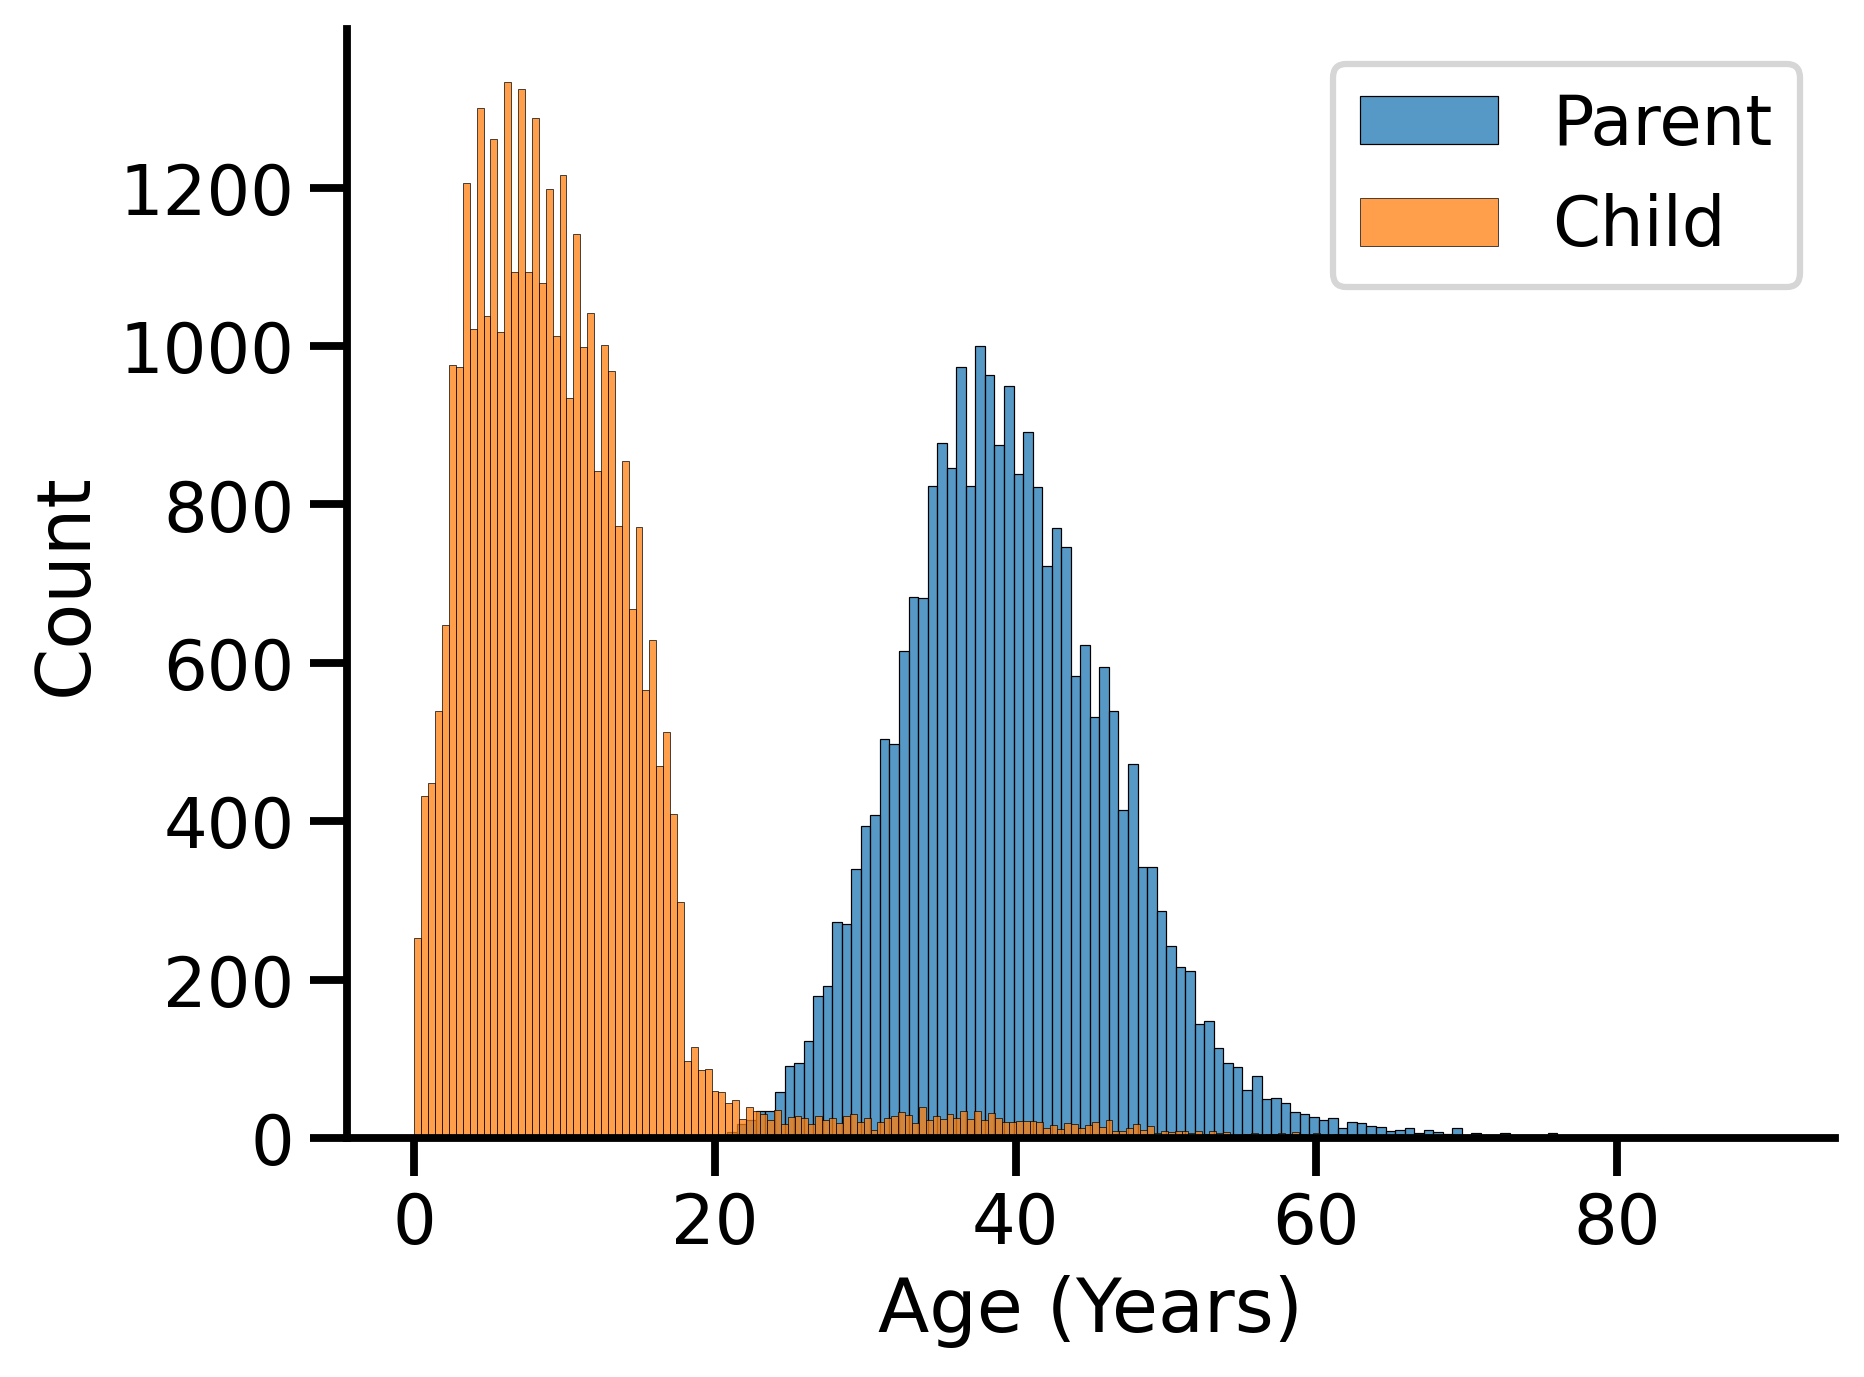

In [7]:
sns.set_context('talk')
plt.figure(dpi = 300)
sns.histplot(metadata[metadata["spid"].isin(parent_spids)]["age_m"]/12, label = "Parent")
sns.histplot(metadata[metadata["spid"].isin(child_spids)]["age_m"]/12, label = "Child")
plt.xlabel("Age (Years)")
sns.despine()
plt.legend()

In [8]:
formatted_sibling_pairs = pd.DataFrame(sibling_df.groupby("spid_affected")["spid_unaffected"].apply(lambda x: ','.join(x))).reset_index()
formatted_sibling_pairs

,spid_affected,spid_unaffected
0,SP0000026,SP0000062
1,SP0000033,SP0000036
2,SP0000145,SP0001673
3,SP0000164,SP0000201
4,SP0000172,SP0000215
...,...,...
18828,SP0558645,SP0558646
18829,SP0558653,SP0558646
18830,SP0558734,SP0558735
18831,SP0558743,SP0558746


In [39]:
formatted_sibling_pairs["spid_affected"].to_csv("../data/asd_spids.txt", header = None, index = None)

In [41]:
sibling_df["spid_unaffected"].drop_duplicates().to_csv("../data/sibling_spids.txt", header = None, index = None)

In [9]:
formatted_sibling_pairs[formatted_sibling_pairs["spid_unaffected"].str.contains(",")]

,spid_affected,spid_unaffected
29,SP0000745,"SP0000781,SP0000813"
71,SP0002414,"SP0002509,SP0002477"
72,SP0002449,"SP0002509,SP0002477"
116,SP0003801,"SP0003802,SP0003804"
119,SP0003927,"SP0004479,SP0004513"
...,...,...
18553,SP0544287,"SP0544289,SP0544290"
18637,SP0547754,"SP0547758,SP0547757"
18638,SP0547755,"SP0547758,SP0547757"
18774,SP0554577,"SP0554581,SP0554580"


In [16]:
np.array(formatted_sibling_pairs["spid_unaffected"].str.count(",").value_counts()) + 1

array([18115,   578,   104,    27,    14])

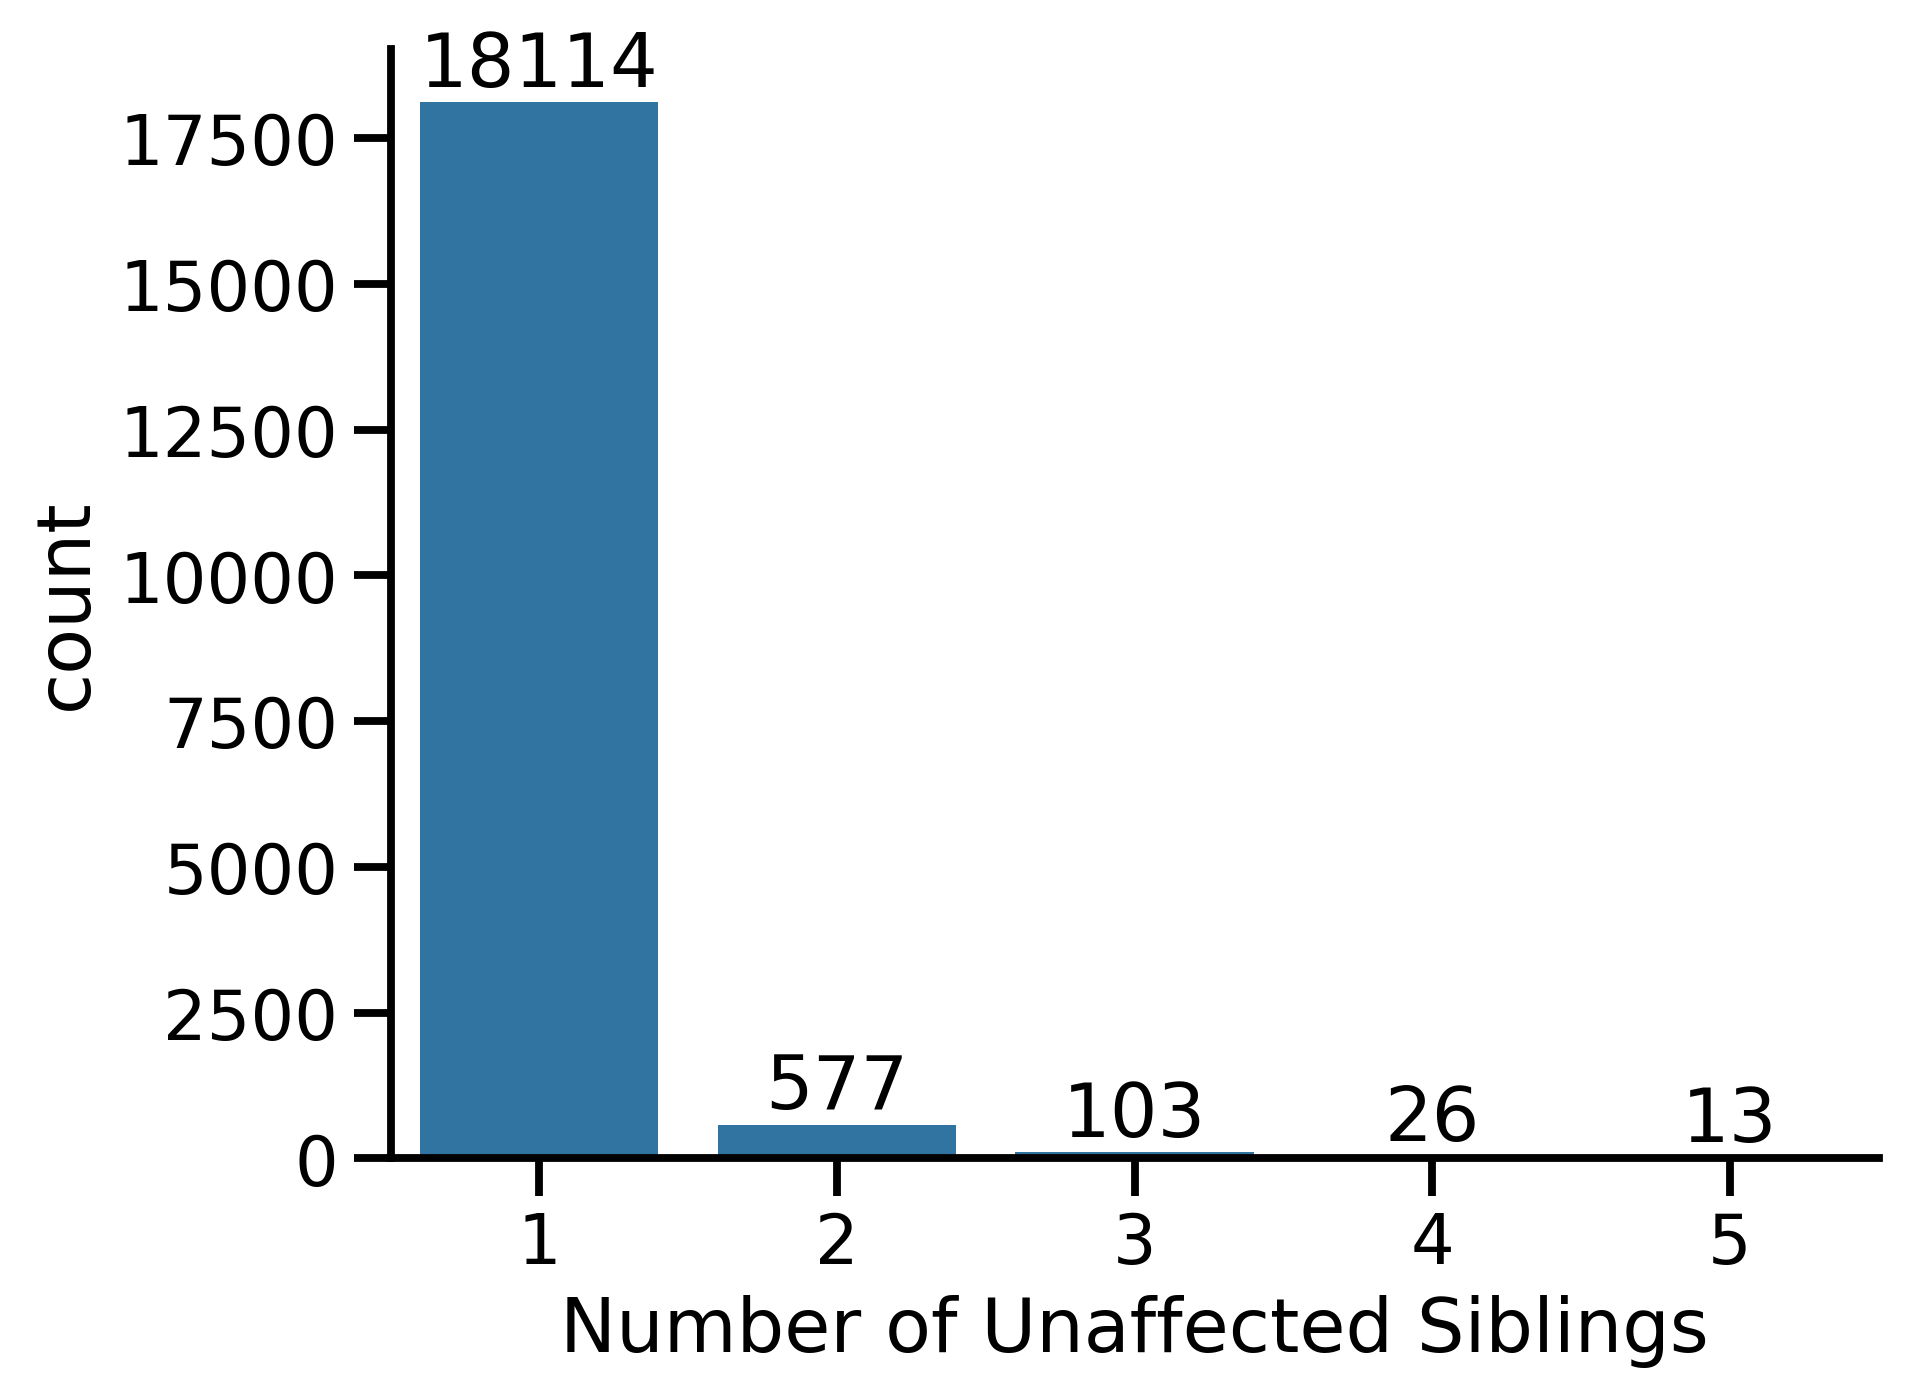

In [32]:
plt.figure(dpi=300)
ax = sns.barplot(
    x=np.arange(1, len(formatted_sibling_pairs["spid_unaffected"].str.count(",").value_counts()) + 1),
    y=formatted_sibling_pairs["spid_unaffected"].str.count(",").value_counts()
)
plt.xlabel("Number of Unaffected Siblings")
sns.despine()

# Add counts to the top of the bars
ax.bar_label(ax.containers[0])

plt.show()

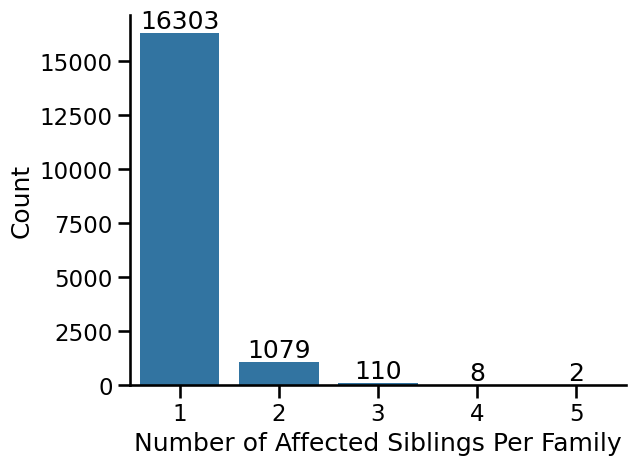

In [34]:
ax = sns.barplot(formatted_sibling_pairs["spid_unaffected"].value_counts().value_counts())
plt.xlabel("Number of Affected Siblings Per Family")
plt.ylabel("Count")

# Add counts to the top of the bars
ax.bar_label(ax.containers[0])
sns.despine()

In [37]:
formatted_sibling_pairs[formatted_sibling_pairs["spid_unaffected"].str.contains(",")].to_csv("../output/sibling_pairs.txt", header = None, index = None)